In [59]:
# PART B - Data preparation with provided datasets
# Ukraine counterfactual inflation project

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Base paths
BASE_DIR = Path.cwd()
if BASE_DIR.name == "code":
    BASE_DIR = BASE_DIR.parent

DATA_DIR = BASE_DIR / "data" / "raw"
PROCESSED_DIR = BASE_DIR / "data" / "processed"
OUTPUT_DIR = BASE_DIR / "outputs"
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

# Input files
ECB_FILE = DATA_DIR / "data_ecb_hicp_panel.csv"
UKR_CPI_FILE = DATA_DIR / "data_ukraine_cpi_raw.csv"
EA_IP_EXTRA_FILE = DATA_DIR / "missingyearsea.xlsx"
UNECE_BACKUP_FILE = DATA_DIR / "ukraine_industrial_production_raw_backup.csv"


In [60]:
# Read euro-area inflation panel
ecb_raw = pd.read_csv(ECB_FILE)
print("ECB panel shape:", ecb_raw.shape)
print(ecb_raw.head())
print("\nColumns:")
print(ecb_raw.columns.tolist())
print("\nMissing values:")
print(ecb_raw.isna().sum())


ECB panel shape: (312, 12)
  TIME_PERIOD   AT   BE   DE   ES   FI   FR   GR   IE   IT   NL   PT
0  2000-01-01  1.4  0.3  1.7  2.9  2.3  1.7  2.3  4.5  2.2  1.6  1.9
1  2000-02-01  1.9  2.1  1.7  3.0  2.7  1.4  2.6  4.6  2.4  1.5  1.6
2  2000-03-01  1.9  2.5  1.4  3.0  3.2  1.6  2.8  5.0  2.5  1.6  1.4
3  2000-04-01  1.8  2.3  1.0  3.0  2.5  1.3  2.1  5.1  2.4  1.7  1.9
4  2000-05-01  1.6  2.4  0.8  3.2  2.7  1.5  2.6  5.1  2.5  2.0  2.4

Columns:
['TIME_PERIOD', 'AT', 'BE', 'DE', 'ES', 'FI', 'FR', 'GR', 'IE', 'IT', 'NL', 'PT']

Missing values:
TIME_PERIOD    0
AT             0
BE             0
DE             0
ES             0
FI             0
FR             0
GR             0
IE             0
IT             0
NL             0
PT             0
dtype: int64


In [61]:
# Copy raw ECB data
ecb_wide_raw = ecb_raw.copy()
# Standardize column names
ecb_wide_raw.columns = [c.strip().lower() for c in ecb_wide_raw.columns]
print(ecb_wide_raw.columns.tolist())


['time_period', 'at', 'be', 'de', 'es', 'fi', 'fr', 'gr', 'ie', 'it', 'nl', 'pt']


In [62]:
ecb_wide = ecb_wide_raw.copy()
# Rename date column
ecb_wide = ecb_wide.rename(columns={"time_period": "date"})
# Parse date
ecb_wide["date"] = pd.to_datetime(ecb_wide["date"], errors="coerce")
# Convert all country columns to numeric
country_cols = [c for c in ecb_wide.columns if c != "date"]
ecb_wide[country_cols] = ecb_wide[country_cols].apply(pd.to_numeric, errors="coerce")
# Drop bad rows if any
ecb_wide = ecb_wide.dropna(subset=["date"]).copy()
# Sort
ecb_wide = ecb_wide.sort_values("date").reset_index(drop=True)
print("ECB wide clean shape:", ecb_wide.shape)
print(ecb_wide.head())
print("\nDate range:", ecb_wide["date"].min(), "to", ecb_wide["date"].max())
print("\nCountry columns:", country_cols)


ECB wide clean shape: (312, 12)
        date   at   be   de   es   fi   fr   gr   ie   it   nl   pt
0 2000-01-01  1.4  0.3  1.7  2.9  2.3  1.7  2.3  4.5  2.2  1.6  1.9
1 2000-02-01  1.9  2.1  1.7  3.0  2.7  1.4  2.6  4.6  2.4  1.5  1.6
2 2000-03-01  1.9  2.5  1.4  3.0  3.2  1.6  2.8  5.0  2.5  1.6  1.4
3 2000-04-01  1.8  2.3  1.0  3.0  2.5  1.3  2.1  5.1  2.4  1.7  1.9
4 2000-05-01  1.6  2.4  0.8  3.2  2.7  1.5  2.6  5.1  2.5  2.0  2.4

Date range: 2000-01-01 00:00:00 to 2025-12-01 00:00:00

Country columns: ['at', 'be', 'de', 'es', 'fi', 'fr', 'gr', 'ie', 'it', 'nl', 'pt']


In [63]:
ecb_long = ecb_wide.melt(
    id_vars="date",
    value_vars=country_cols,
    var_name="country",
    value_name="inflation_yoy"
).sort_values(["country", "date"]).reset_index(drop=True)
print("ECB long shape:", ecb_long.shape)
print(ecb_long.head())
print("\nCountries:", sorted(ecb_long["country"].unique()))
ecb_long.to_csv(PROCESSED_DIR / "ecb_hicp_panel_long_clean.csv", index=False)


ECB long shape: (3432, 3)
        date country  inflation_yoy
0 2000-01-01      at            1.4
1 2000-02-01      at            1.9
2 2000-03-01      at            1.9
3 2000-04-01      at            1.8
4 2000-05-01      at            1.6

Countries: ['at', 'be', 'de', 'es', 'fi', 'fr', 'gr', 'ie', 'it', 'nl', 'pt']


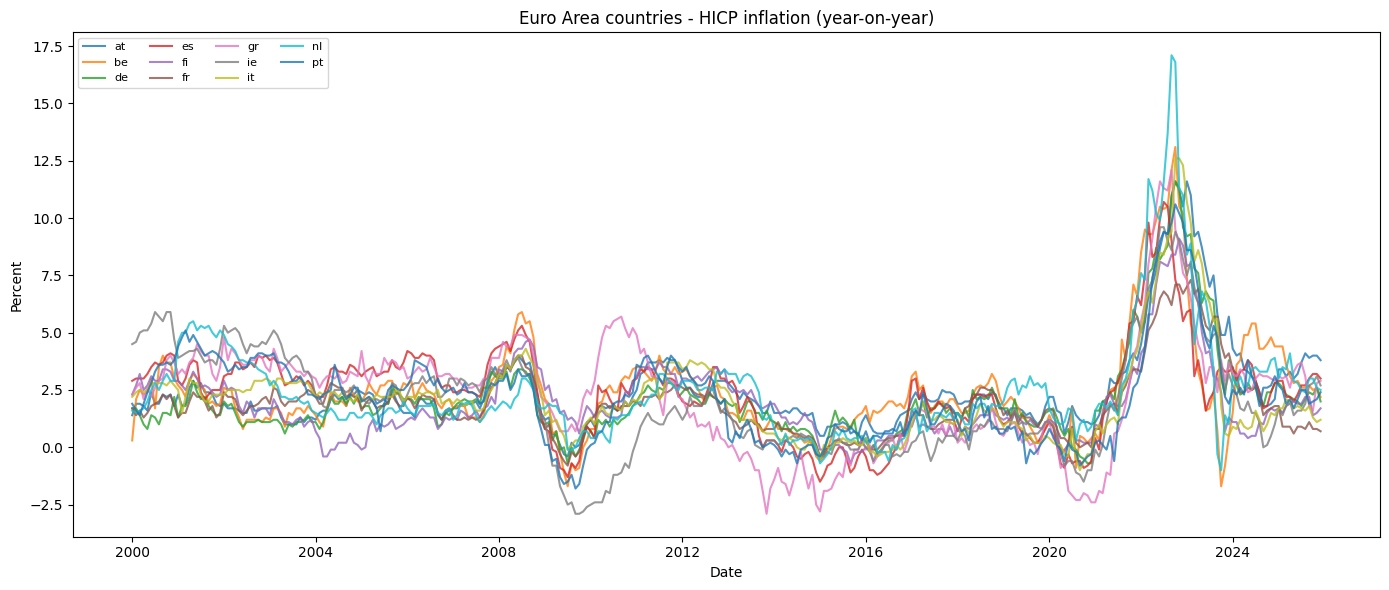

In [64]:
plt.figure(figsize=(14, 6))
for col in country_cols:
    plt.plot(ecb_wide["date"], ecb_wide[col], label=col, alpha=0.8)

plt.title("Euro Area countries - HICP inflation (year-on-year)")
plt.xlabel("Date")
plt.ylabel("Percent")
plt.legend(ncol=4, fontsize=8)
plt.tight_layout()
plt.show()


In [65]:
# UKRAINE CPI RAW
#  Read raw Ukraine CPI dataset
ukr_raw = pd.read_csv(UKR_CPI_FILE)
print("Ukraine CPI raw shape:", ukr_raw.shape)
print(ukr_raw.head())
print("\nColumns:")
print(ukr_raw.columns.tolist())
print("\nMissing values:")
print(ukr_raw.isna().sum())
 # Standardize column names
ukr_raw.columns = [c.strip().lower() for c in ukr_raw.columns]
print("\nStandardized column names:")
print(ukr_raw.columns.tolist())


Ukraine CPI raw shape: (312, 26)
   Unnamed: 0 STRUCTURE[;]                                       STRUCTURE_ID  \
0           0     dataflow  SSSU:DF_PRICE_CHANGE_CONSUMER_GOODS_SERVICE(27...   
1           1     dataflow  SSSU:DF_PRICE_CHANGE_CONSUMER_GOODS_SERVICE(27...   
2           2     dataflow  SSSU:DF_PRICE_CHANGE_CONSUMER_GOODS_SERVICE(27...   
3           3     dataflow  SSSU:DF_PRICE_CHANGE_CONSUMER_GOODS_SERVICE(27...   
4           4     dataflow  SSSU:DF_PRICE_CHANGE_CONSUMER_GOODS_SERVICE(27...   

  ACTION          INDICATOR BASE_PERIOD               REGION  \
0      R  INDEX_CONSUMPRICE  PREV_MONTH  UA00000000000000000   
1      R  INDEX_CONSUMPRICE  PREV_MONTH  UA00000000000000000   
2      R  INDEX_CONSUMPRICE  PREV_MONTH  UA00000000000000000   
3      R  INDEX_CONSUMPRICE  PREV_MONTH  UA00000000000000000   
4      R  INDEX_CONSUMPRICE  PREV_MONTH  UA00000000000000000   

   GOODS_SERVICES_TYPE FREQ TIME_PERIOD  ...     UPDATED  NEXT_UPDATE  \
0                    0

In [66]:
#  Keep only needed columns
ukr = ukr_raw[["time_period", "obs_value"]].copy()
ukr = ukr.rename(columns={
    "time_period": "date",
    "obs_value": "cpi_mom_index"
})

#  Parse date and values
# TIME_PERIOD format: 2000-M01
ukr["date"] = pd.to_datetime(
    ukr["date"].str.replace("-M", "-", regex=False),
    format="%Y-%m",
    errors="coerce"
)

ukr["cpi_mom_index"] = pd.to_numeric(ukr["cpi_mom_index"], errors="coerce")

ukr = ukr.dropna(subset=["date", "cpi_mom_index"]).copy()
ukr = ukr.sort_values("date").reset_index(drop=True)

print(ukr.head())
print("\nDate range:", ukr["date"].min(), "to", ukr["date"].max())

#Reconstruct chained price index
# OBS_VALUE is an index with previous month = 100
# Example: 101.5 means monthly inflation of 1.5%
ukr["monthly_factor"] = ukr["cpi_mom_index"] / 100.0

# Synthetic chained price index starting at 100
ukr["price_index"] = 100.0 * ukr["monthly_factor"].cumprod()

# Compute year-on-year inflation, the first 12 observations are missing by construction
ukr["inflation_yoy"] = (ukr["price_index"] / ukr["price_index"].shift(12) - 1.0) * 100.0

# lets checks
print("\nMissing yoy observations:", ukr["inflation_yoy"].isna().sum())
print("First non-missing yoy date:", ukr.loc[ukr["inflation_yoy"].notna(), "date"].min())
print("Last available date:", ukr["date"].max())

ukr_summary = {
    "n_obs_total": len(ukr),
    "n_obs_yoy_non_missing": ukr["inflation_yoy"].notna().sum(),
    "inflation_yoy_mean": ukr["inflation_yoy"].mean(),
    "inflation_yoy_std": ukr["inflation_yoy"].std(),
    "inflation_yoy_min": ukr["inflation_yoy"].min(),
    "inflation_yoy_max": ukr["inflation_yoy"].max()
}

print("\nSummary stats:")
for k, v in ukr_summary.items():
    print(f"{k}: {v}")
# Save full cleaned dataset
ukr.to_csv(PROCESSED_DIR / "ukraine_inflation_yoy_clean.csv", index=False)

ukr_summary_df = pd.DataFrame([ukr_summary])
ukr_summary_df.to_csv(PROCESSED_DIR / "ukraine_inflation_summary.csv", index=False)

# Save analysis-ready version
ukr_analysis = ukr[["date", "inflation_yoy"]].dropna().copy()
ukr_analysis = ukr_analysis.rename(columns={"inflation_yoy": "ukraine_inflation_yoy"})

print("\nAnalysis-ready Ukraine inflation series:")
print(ukr_analysis.head())
print(ukr_analysis.tail())

ukr_analysis.to_csv(PROCESSED_DIR / "ukraine_inflation_analysis_ready.csv", index=False)
# 3 files saved in total:"ukraine_inflation_yoy_clean.csv","ukraine_inflation_summary.csv"), "ukraine_inflation_analysis_ready.csv")


        date  cpi_mom_index
0 2000-01-01          104.6
1 2000-02-01          103.3
2 2000-03-01          102.0
3 2000-04-01          101.7
4 2000-05-01          102.1

Date range: 2000-01-01 00:00:00 to 2025-12-01 00:00:00

Missing yoy observations: 12
First non-missing yoy date: 2001-01-01 00:00:00
Last available date: 2025-12-01 00:00:00

Summary stats:
n_obs_total: 312
n_obs_yoy_non_missing: 300
inflation_yoy_mean: 11.814886433442796
inflation_yoy_std: 10.398314181184771
inflation_yoy_min: -1.2040685119400818
inflation_yoy_max: 60.90567462067749

Analysis-ready Ukraine inflation series:
         date  ukraine_inflation_yoy
12 2001-01-01              22.087222
13 2001-02-01              18.896172
14 2001-03-01              17.264263
15 2001-04-01              17.033655
16 2001-05-01              15.085005
          date  ukraine_inflation_yoy
307 2025-08-01              13.212290
308 2025-09-01              11.873820
309 2025-10-01              10.884759
310 2025-11-01              

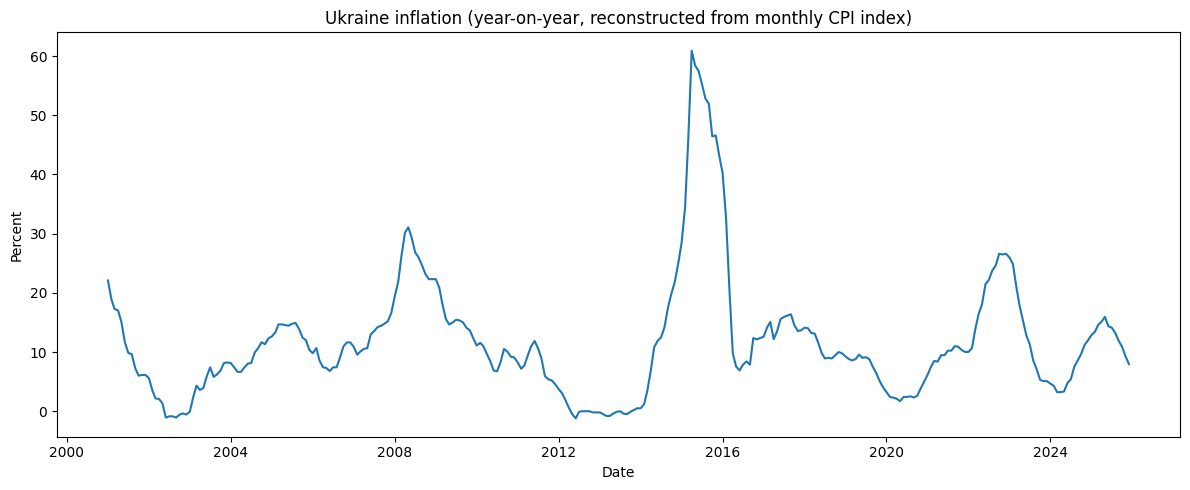

In [67]:

ukr_analysis = ukr[["date", "inflation_yoy"]].dropna().copy()
ukr_analysis = ukr_analysis.rename(columns={"inflation_yoy": "ukraine_inflation_yoy"})
plt.figure(figsize=(12, 5))
plt.plot(ukr_analysis["date"], ukr_analysis["ukraine_inflation_yoy"])
plt.title("Ukraine inflation (year-on-year, reconstructed from monthly CPI index)")
plt.xlabel("Date")
plt.ylabel("Percent")
plt.tight_layout()
plt.show()


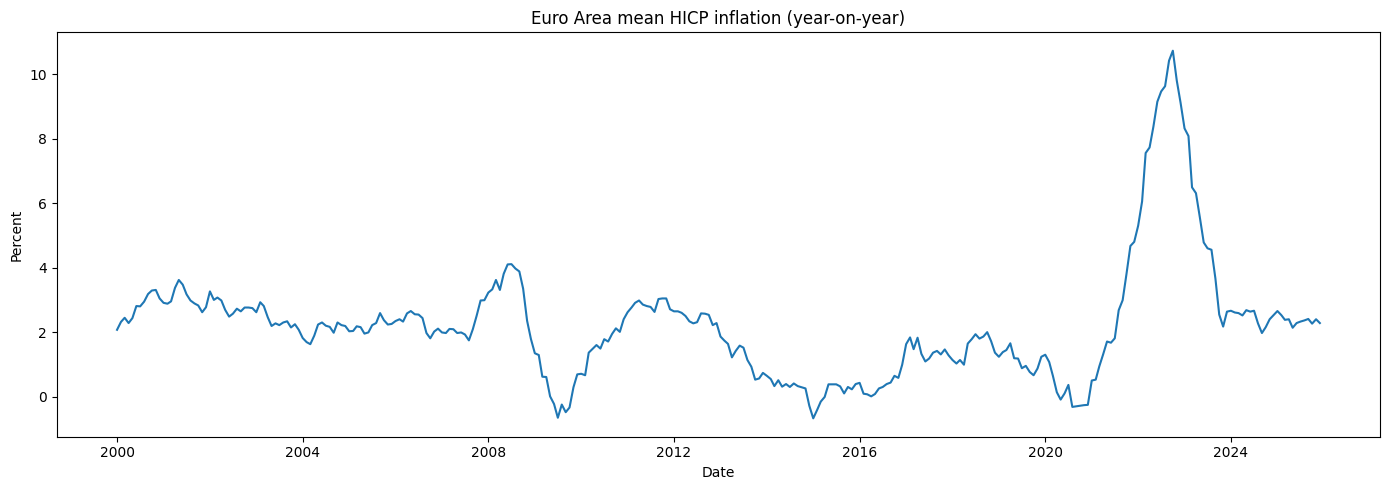

In [68]:
# The provided ECB file contains country-level HICP inflation series, but no Euro Area aggregate.
# use of a simple cross-country average as a proxy for Euro Area inflation in the VAR.
ea_mean = (
    ecb_wide.copy()
    .assign(ea_mean_inflation_yoy=ecb_wide[country_cols].mean(axis=1))
    [["date", "ea_mean_inflation_yoy"]]
)

plt.figure(figsize=(14, 5))
plt.plot(ea_mean["date"], ea_mean["ea_mean_inflation_yoy"])
plt.title("Euro Area mean HICP inflation (year-on-year)")
plt.xlabel("Date")
plt.ylabel("Percent")
plt.tight_layout()
plt.show()


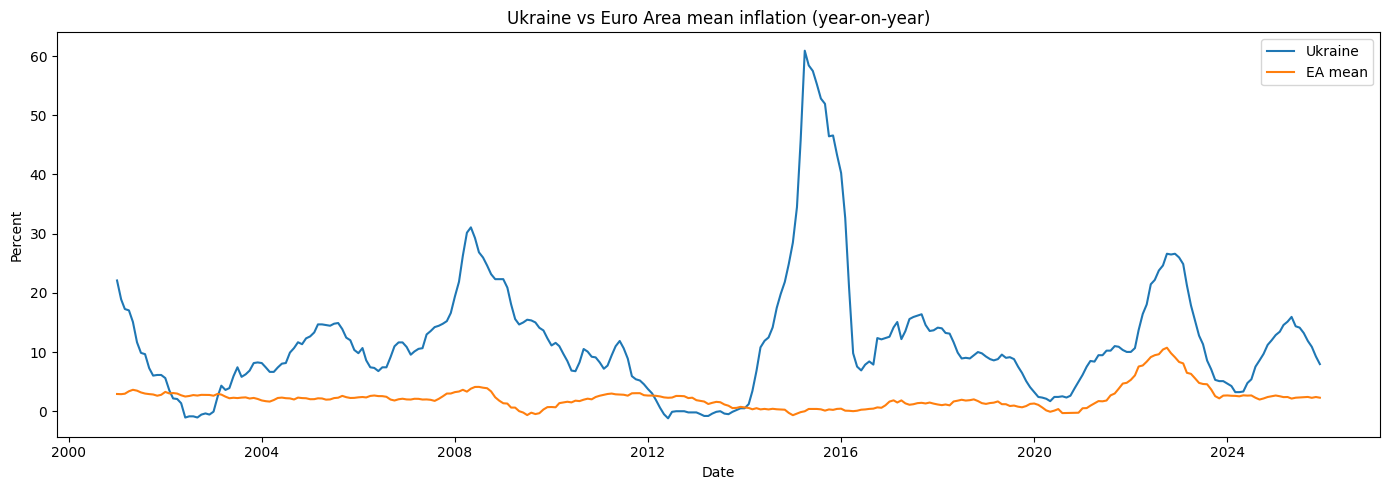

In [69]:

ea_mean = (
    ecb_wide.copy()
    .assign(ea_mean_inflation_yoy=ecb_wide[country_cols].mean(axis=1))
    [["date", "ea_mean_inflation_yoy"]]
)
compare_df = pd.merge(
    ukr_analysis,
    ea_mean,
    on="date",
    how="inner"
).sort_values("date")

plt.figure(figsize=(14, 5))
plt.plot(compare_df["date"], compare_df["ukraine_inflation_yoy"], label="Ukraine")
plt.plot(compare_df["date"], compare_df["ea_mean_inflation_yoy"], label="EA mean")
plt.title("Ukraine vs Euro Area mean inflation (year-on-year)")
plt.xlabel("Date")
plt.ylabel("Percent")
plt.legend()
plt.tight_layout()
plt.show()


### Industrial production series used

For Ukraine, I use the UNECE monthly industrial production index, seasonally adjusted (2021 = 100). For the Euro Area, I use Eurostat `sts_inpr_m` with `nace_r2 = B-D`, `s_adj = SCA`, and `unit = I15`.
The two  series come from different sources and have different base years. I therefore do not use them in levels. Both are transformed into 12 month log diff and used as real activity growth proxies. This keeps the VAR focused on yoy dynamics, while the source difference remains a limitation.

In [70]:
# download Euro Area industrial production from API
# use Excel only for the missing years after 2023

import requests
import pandas as pd

url = "https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data/sts_inpr_m"

# this function downloads one series depending on the geo code I give it
def get_ip_series(geo_code):

    params = {
        "geo": geo_code,
        "nace_r2": "B-D",
        "s_adj": "SCA",
        "unit": "I15"
    }

    r = requests.get(url, params=params, timeout=60)
    data = r.json()

    time_keys = list(data["dimension"]["time"]["category"]["label"].keys())
    values = data["value"]

    rows = []

    # build a simple table with date, value and geo
    for k, v in values.items():
        idx = int(k)

        rows.append({
            "date": pd.to_datetime(time_keys[idx], format="%Y-%m"),
            "value": v,
            "geo": geo_code
        })

    df = pd.DataFrame(rows)

    # sort by date just to keep it clean
    df = df.sort_values("date").reset_index(drop=True)

    return df


# download EA19
ea19 = get_ip_series("EA19")

# download EA20
ea20 = get_ip_series("EA20")


# read the horizontal Excel file
ea20_extra_raw = pd.read_excel(EA_IP_EXTRA_FILE, header=0)

# first row contains the values
row = ea20_extra_raw.iloc[0]

dates = []
values = []

# all columns except first text column
for col in ea20_extra_raw.columns[1:]:
    dates.append(col)
    values.append(row[col])

ea20_extra = pd.DataFrame({
    "date": dates,
    "value": values
})

# keep monthly labels only
ea20_extra = ea20_extra[
    ea20_extra["date"].astype(str).str.match(r"^\d{4}-\d{2}$")
].copy()

# convert date and value
ea20_extra["date"] = pd.to_datetime(ea20_extra["date"], format="%Y-%m")
ea20_extra["value"] = pd.to_numeric(ea20_extra["value"], errors="coerce")

# keep only missing years
ea20_extra = ea20_extra[
    ea20_extra["date"] >= "2024-01-01"
].copy()

ea20_extra["geo"] = "EA20"

ea20_extra = ea20_extra[["date", "value", "geo"]].copy()


# combine API data with missing years
ea20 = pd.concat([ea20, ea20_extra], ignore_index=True)

# sort again
ea20 = ea20.sort_values("date").reset_index(drop=True)


# keep EA19 only until the end of 2022
ea19 = ea19[ea19["date"] <= "2022-12-01"].copy()

# keep EA20 only from 2023 onward
ea20 = ea20[ea20["date"] >= "2023-01-01"].copy()

# combine both parts
ea_ip = pd.concat([ea19, ea20], ignore_index=True)

# sort again by date
ea_ip = ea_ip.sort_values("date").reset_index(drop=True)

# keep only the period I need for the project
ea_ip = ea_ip[ea_ip["date"] >= "2000-01-01"].copy()

# rename the main column so it is clearer
ea_ip = ea_ip.rename(columns={"value": "euro_area_ip"})

# look at the result
print(ea_ip.head())
print(ea_ip.tail())
print(ea_ip.shape)

# lets save the Euro Area industrial production series
ea_ip.to_csv(PROCESSED_DIR / "euro_area_industrial_production.csv", index=False)


          date  euro_area_ip   geo
108 2000-01-01          92.1  EA19
109 2000-02-01          93.2  EA19
110 2000-03-01          93.6  EA19
111 2000-04-01          94.7  EA19
112 2000-05-01          96.0  EA19
          date  euro_area_ip   geo
417 2025-10-01          98.8  EA20
418 2025-11-01          99.0  EA20
419 2025-12-01          98.3  EA20
420 2026-01-01          97.6  EA20
421 2026-02-01          97.9  EA20
(314, 3)


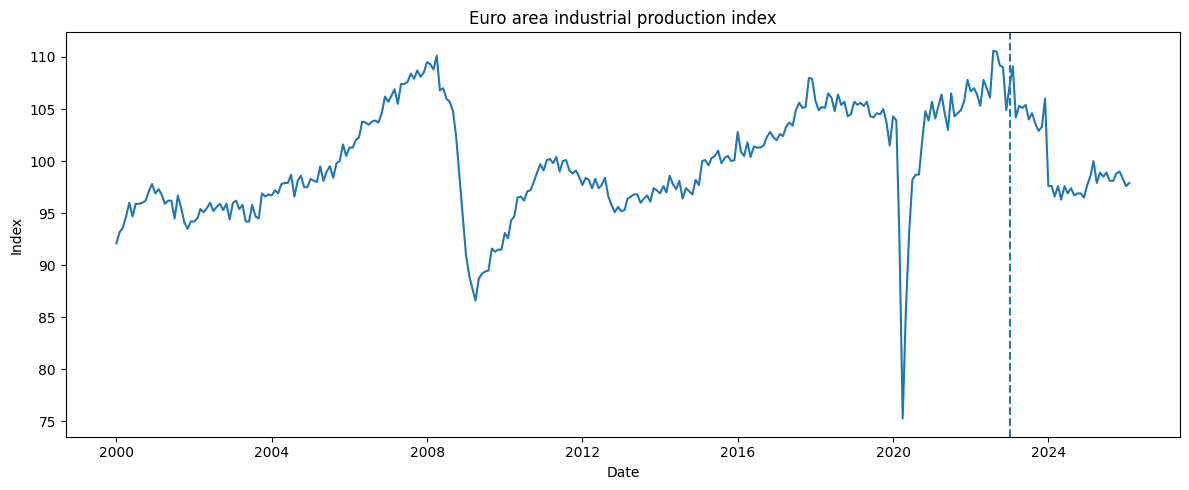

In [71]:
# Plot to see if the break in the series looks ok
plt.figure(figsize=(12, 5))
plt.plot(ea_ip["date"], ea_ip["euro_area_ip"])
plt.axvline(pd.to_datetime("2023-01-01"), linestyle="--")
plt.title("Euro area industrial production index")
plt.xlabel("Date")
plt.ylabel("Index")
plt.tight_layout()
plt.show()


In [72]:

# UNECE API for Ukraine industrial production, seasonally adjusted
unece_url = "https://w3.unece.org/PXWeb2015/api/v1/en/STAT/20-ME/5-MEPW/3_en_MECCIndProdM_r.px"

payload = {
    "query": [
        {
            "code": "Indicator",
            "selection": {
                "filter": "item",
                "values": ["c0000735"]   # seasonally adjusted index, 2021=100
            }
        },
        {
            "code": "Country",
            "selection": {
                "filter": "item",
                "values": ["804"]   # Ukraine
            }
        },
        {
            "code": "Month",
            "selection": {
                "filter": "all",
                "values": ["*"]
            }
        }
    ],
    "response": {
        "format": "csv"
    }
}

r = requests.post(unece_url, json=payload, timeout=60)

print(r.status_code)
print(r.text[:1200])


200
"Indicator","Country","1990M01","1990M02","1990M03","1990M04","1990M05","1990M06","1990M07","1990M08","1990M09","1990M10","1990M11","1990M12","1991M01","1991M02","1991M03","1991M04","1991M05","1991M06","1991M07","1991M08","1991M09","1991M10","1991M11","1991M12","1992M01","1992M02","1992M03","1992M04","1992M05","1992M06","1992M07","1992M08","1992M09","1992M10","1992M11","1992M12","1993M01","1993M02","1993M03","1993M04","1993M05","1993M06","1993M07","1993M08","1993M09","1993M10","1993M11","1993M12","1994M01","1994M02","1994M03","1994M04","1994M05","1994M06","1994M07","1994M08","1994M09","1994M10","1994M11","1994M12","1995M01","1995M02","1995M03","1995M04","1995M05","1995M06","1995M07","1995M08","1995M09","1995M10","1995M11","1995M12","1996M01","1996M02","1996M03","1996M04","1996M05","1996M06","1996M07","1996M08","1996M09","1996M10","1996M11","1996M12","1997M01","1997M02","1997M03","1997M04","1997M05","1997M06","1997M07","1997M08","1997M09","1997M10","1997M11","1997M12","1998M01","199

In [73]:
# alternative if api does not work, I have saved the csv response in the data folder, so we can read it directly :c
from io import StringIO

# if the API works, use the response
# if not, use the backup csv file

if r.status_code == 200 and "Too many requests" not in r.text and not r.text.strip().startswith('{"error"'):
    ukr_unece_raw = pd.read_csv(StringIO(r.text))
    print("UNECE data loaded from API")
else:
    ukr_unece_raw = pd.read_csv(UNECE_BACKUP_FILE)
    print("UNECE API unavailable, backup file loaded instead")

print(ukr_unece_raw.head())
print(ukr_unece_raw.columns.tolist())
print(ukr_unece_raw.tail())


UNECE data loaded from API
                                           Indicator  Country 1990M01 1990M02  \
0  Industrial Production index, seasonally adjust...  Ukraine      ..      ..   

  1990M03 1990M04 1990M05 1990M06 1990M07 1990M08  ... 2025M05 2025M06  \
0      ..      ..      ..      ..      ..      ..  ...    71.6    71.6   

  2025M07 2025M08 2025M09 2025M10 2025M11 2025M12 2026M01 2026M02  
0    70.8    70.4    71.6    69.2    68.0    68.2    65.4      ..  

[1 rows x 436 columns]
['Indicator', 'Country', '1990M01', '1990M02', '1990M03', '1990M04', '1990M05', '1990M06', '1990M07', '1990M08', '1990M09', '1990M10', '1990M11', '1990M12', '1991M01', '1991M02', '1991M03', '1991M04', '1991M05', '1991M06', '1991M07', '1991M08', '1991M09', '1991M10', '1991M11', '1991M12', '1992M01', '1992M02', '1992M03', '1992M04', '1992M05', '1992M06', '1992M07', '1992M08', '1992M09', '1992M10', '1992M11', '1992M12', '1993M01', '1993M02', '1993M03', '1993M04', '1993M05', '1993M06', '1993M07', '19

In [74]:
# make a working copy
ukr_unece = ukr_unece_raw.copy()

# normalize the structure if needed
# API output and backup file do not have exactly the same header format
# case 1: backup file with embedded header row
if "indicator" not in [c.strip().lower() for c in ukr_unece.columns]:
    # second row contains the real column names
    new_cols = ukr_unece.iloc[1].tolist()

    # first column is the indicator label
    new_cols[0] = "indicator"
    new_cols[1] = "country"

    ukr_unece = ukr_unece.iloc[2:].copy()
    ukr_unece.columns = new_cols

# keep column names simple
ukr_unece.columns = [str(c).strip().lower() for c in ukr_unece.columns]

# month columns look like 2000m01, 2000m02, ...
month_cols = [c for c in ukr_unece.columns if len(c) == 7 and c[:4].isdigit() and c[4] == "m"]

# move from wide to long format
ukr_unece = ukr_unece.melt(
    id_vars=["indicator", "country"],
    value_vars=month_cols,
    var_name="date",
    value_name="ukraine_ip"
)

# turn strings like 2000m01 into real dates
ukr_unece["date"] = pd.to_datetime(
    ukr_unece["date"].str.replace("m", "-", regex=False),
    format="%Y-%m",
    errors="coerce"
)

# make the index numeric
ukr_unece["ukraine_ip"] = pd.to_numeric(ukr_unece["ukraine_ip"], errors="coerce")

# drop empty rows and sort
ukr_unece = ukr_unece.dropna(subset=["date", "ukraine_ip"]).copy()
ukr_unece = ukr_unece.sort_values("date").reset_index(drop=True)

print(ukr_unece.head(15))
print(ukr_unece["date"].min(), ukr_unece["date"].max())


                                            indicator  country       date  \
0   Industrial Production index, seasonally adjust...  Ukraine 2000-01-01   
1   Industrial Production index, seasonally adjust...  Ukraine 2000-02-01   
2   Industrial Production index, seasonally adjust...  Ukraine 2000-03-01   
3   Industrial Production index, seasonally adjust...  Ukraine 2000-04-01   
4   Industrial Production index, seasonally adjust...  Ukraine 2000-05-01   
5   Industrial Production index, seasonally adjust...  Ukraine 2000-06-01   
6   Industrial Production index, seasonally adjust...  Ukraine 2000-07-01   
7   Industrial Production index, seasonally adjust...  Ukraine 2000-08-01   
8   Industrial Production index, seasonally adjust...  Ukraine 2000-09-01   
9   Industrial Production index, seasonally adjust...  Ukraine 2000-10-01   
10  Industrial Production index, seasonally adjust...  Ukraine 2000-11-01   
11  Industrial Production index, seasonally adjust...  Ukraine 2000-12-01   

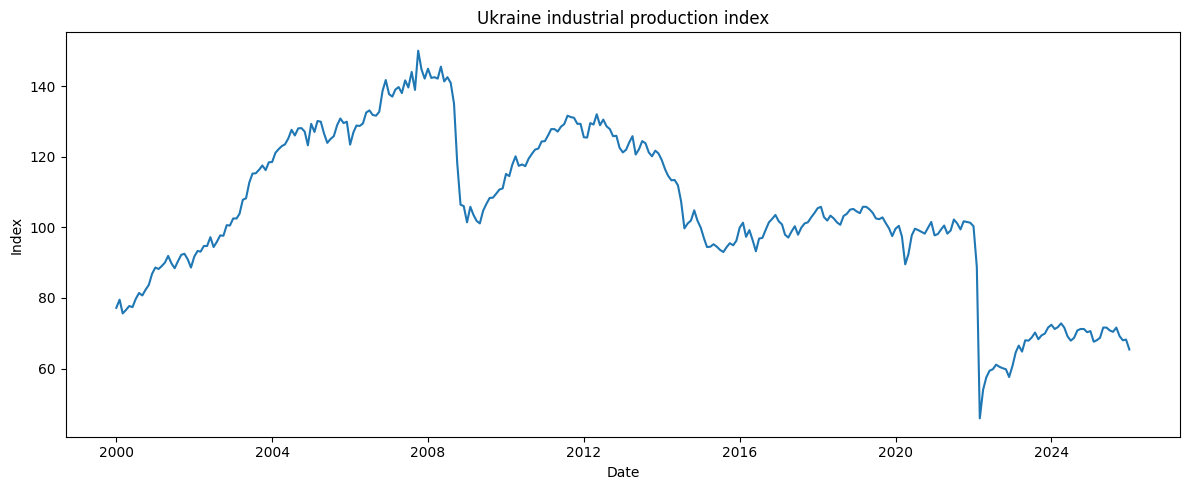

In [75]:
# graph to see if the series looks ok
plt.figure(figsize=(12, 5))
plt.plot(ukr_unece["date"], ukr_unece["ukraine_ip"])
plt.title("Ukraine industrial production index")
plt.xlabel("Date")
plt.ylabel("Index")
plt.tight_layout()
plt.show()


### Oil

In [76]:
#oil dataset as exogenous variable for the model
fred_oil_url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=POILAPSPUSDM"

oil = pd.read_csv(fred_oil_url)
oil.columns = ["date", "oil_price"]

oil["date"] = pd.to_datetime(oil["date"], errors="coerce")
oil["oil_price"] = pd.to_numeric(oil["oil_price"], errors="coerce")

oil = oil.dropna().copy()
oil = oil[
    (oil["date"] >= "2000-01-01") &
    (oil["date"] <= "2025-12-01")
].copy()

oil["oil_yoy"] = 100 * (
    np.log(oil["oil_price"]) - np.log(oil["oil_price"].shift(12))
)

oil_df = oil[["date", "oil_yoy"]].dropna().reset_index(drop=True)


In [77]:

# keep only what I need from industrial production datasets
ukr_ip = ukr_unece[["date", "ukraine_ip"]].copy()
ea_ip_use = ea_ip[["date", "euro_area_ip"]].copy()

# merge both industrial production series
ip_panel = pd.merge(
    ukr_ip,
    ea_ip_use,
    on="date",
    how="inner"
).sort_values("date").reset_index(drop=True)

# keep common sample for the project
ip_panel = ip_panel[
    (ip_panel["date"] >= "2000-01-01") &
    (ip_panel["date"] <= "2025-12-01")
].copy()

print(ip_panel.head())


        date  ukraine_ip  euro_area_ip
0 2000-01-01        77.2          92.1
1 2000-02-01        79.5          93.2
2 2000-03-01        75.6          93.6
3 2000-04-01        76.6          94.7
4 2000-05-01        77.7          96.0


In [78]:
# transformations for ip:
# 12-month log differences
ip_panel["ukraine_ip_yoy"] = 100 * (
    np.log(ip_panel["ukraine_ip"]) - np.log(ip_panel["ukraine_ip"].shift(12))
)

ip_panel["euro_area_ip_yoy"] = 100 * (
    np.log(ip_panel["euro_area_ip"]) - np.log(ip_panel["euro_area_ip"].shift(12))
)

ip_panel_yoy = ip_panel[["date", "ukraine_ip_yoy", "euro_area_ip_yoy"]].dropna().copy()

print(ip_panel_yoy.head())
print(ip_panel_yoy.tail())
print(ip_panel_yoy["date"].min(), ip_panel_yoy["date"].max())
print(len(ip_panel_yoy))
#For example, a value of 13.77 in ukraine_ip_yoy for 2001-01 means that Ukraine’s industrial production was approximately 13.8% higher than in January 2000.


         date  ukraine_ip_yoy  euro_area_ip_yoy
12 2001-01-01       13.773240          5.080458
13 2001-02-01       10.384994          4.305127
14 2001-03-01       16.318009          3.361661
15 2001-04-01       16.121259          1.259198
16 2001-05-01       16.784577          0.208117
          date  ukraine_ip_yoy  euro_area_ip_yoy
307 2025-08-01        2.444406          0.716116
308 2025-09-01        1.123607          1.437396
309 2025-10-01       -2.849196          1.941809
310 2025-11-01       -4.598511          2.144033
311 2025-12-01       -3.032723          1.848102
2001-01-01 00:00:00 2025-12-01 00:00:00
300


It is normal for Ukraine’s industrial production growth to be more volatile and often higher than that of the Euro Area, since Ukraine is a smaller and more shock-sensitive economy, while the Euro Area is a larger and more diversified aggregate.

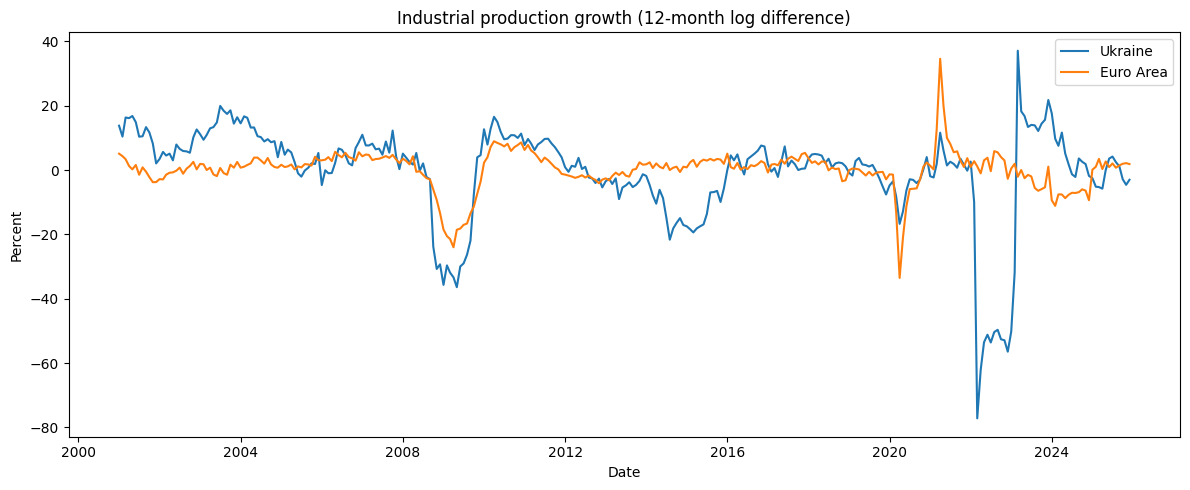

In [79]:
plt.figure(figsize=(12, 5))
plt.plot(ip_panel_yoy["date"], ip_panel_yoy["ukraine_ip_yoy"], label="Ukraine")
plt.plot(ip_panel_yoy["date"], ip_panel_yoy["euro_area_ip_yoy"], label="Euro Area")
plt.title("Industrial production growth (12-month log difference)")
plt.xlabel("Date")
plt.ylabel("Percent")
plt.legend()
plt.tight_layout()
plt.show()


In [80]:
# simple euro area inflation aggregate for the Euro Area VAR
ea_inflation = (
    ecb_wide.copy()
    .assign(euro_area_inflation_yoy=ecb_wide[country_cols].mean(axis=1))
    [["date", "euro_area_inflation_yoy"]]
    .sort_values("date")
    .reset_index(drop=True)
)
print(ea_inflation.head())
print(ea_inflation.tail())
#Euro Area inflation is proxied by the simple average of the country-level inflation series provided in the dataset.


        date  euro_area_inflation_yoy
0 2000-01-01                 2.072727
1 2000-02-01                 2.318182
2 2000-03-01                 2.445455
3 2000-04-01                 2.281818
4 2000-05-01                 2.436364
          date  euro_area_inflation_yoy
307 2025-08-01                 2.363636
308 2025-09-01                 2.409091
309 2025-10-01                 2.263636
310 2025-11-01                 2.400000
311 2025-12-01                 2.281818


In [81]:
# first I build the Ukraine model dataset with the two core endogenous variables:
# inflation and industrial production growth
# I only keep the columns I need for the SVAR block
ukr_var_df = pd.merge(
    ukr_analysis[["date", "ukraine_inflation_yoy"]],
    ip_panel_yoy[["date", "ukraine_ip_yoy"]],
    on="date",
    how="inner"
)
# now I add oil to the same monthly dataset
# oil is not part of the core [output, inflation] block
# I merge it here because I want it available later as an exogenous variable
# inner join keeps only dates that exist in all series
ukr_var_df = pd.merge(
    ukr_var_df,
    oil_df,
    on="date",
    how="inner"
).sort_values("date").reset_index(drop=True)

# same idea for the Euro Area:
# build the dataset with Euro Area inflation and industrial production growth
# this gives me the comparable macro block for the EA side
ea_var_df = pd.merge(
    ea_inflation,
    ip_panel_yoy[["date", "euro_area_ip_yoy"]],
    on="date",
    how="inner"
)
# add the same oil series here too
# oil is common and external, so I want it aligned with both datasets
ea_var_df = pd.merge(
    ea_var_df,
    oil_df,
    on="date",
    how="inner"
).sort_values("date").reset_index(drop=True)

# quick check:
# look at the first and last rows
# check the common sample after all merges
# check if merging oil shortened the sample too much
# check missing values before estimating anything
print("Ukraine VAR data")
print(ukr_var_df.head())
print(ukr_var_df.tail())
print(ukr_var_df["date"].min(), ukr_var_df["date"].max())
print(len(ukr_var_df))
print(ukr_var_df.isna().sum())

print("\nEuro Area VAR data")
print(ea_var_df.head())
print(ea_var_df.tail())
print(ea_var_df["date"].min(), ea_var_df["date"].max())
print(len(ea_var_df))
print(ea_var_df.isna().sum()) 
# 300 obs for both datasets


Ukraine VAR data
        date  ukraine_inflation_yoy  ukraine_ip_yoy   oil_yoy
0 2001-01-01              22.087222       13.773240  2.153811
1 2001-02-01              18.896172       10.384994  0.220359
2 2001-03-01              17.264263       16.318009 -8.380435
3 2001-04-01              17.033655       16.121259  8.619002
4 2001-05-01              15.085005       16.784577  0.240691
          date  ukraine_inflation_yoy  ukraine_ip_yoy    oil_yoy
295 2025-08-01              13.212290        2.444406 -15.717260
296 2025-09-01              11.873820        1.123607  -7.526738
297 2025-10-01              10.884759       -2.849196 -16.537049
298 2025-11-01               9.252500       -4.598511 -14.546201
299 2025-12-01               7.959571       -3.032723 -17.941512
2001-01-01 00:00:00 2025-12-01 00:00:00
300
date                     0
ukraine_inflation_yoy    0
ukraine_ip_yoy           0
oil_yoy                  0
dtype: int64

Euro Area VAR data
        date  euro_area_inflation_yo

In [82]:
common_start = max(ukr_var_df["date"].min(), ea_var_df["date"].min())
common_end = min(ukr_var_df["date"].max(), ea_var_df["date"].max())

ukr_var_df = ukr_var_df[
    (ukr_var_df["date"] >= common_start) &
    (ukr_var_df["date"] <= common_end)
].copy()

ea_var_df = ea_var_df[
    (ea_var_df["date"] >= common_start) &
    (ea_var_df["date"] <= common_end)
].copy()

print(common_start, common_end)
print(len(ukr_var_df), len(ea_var_df))


2001-01-01 00:00:00 2025-12-01 00:00:00
300 300


Lets do a quick visual check of the two endogenous VAR series:
 look for major crises, volatility spikes, breaks, and whether inflation and activity move in a  macro pattern before estimation

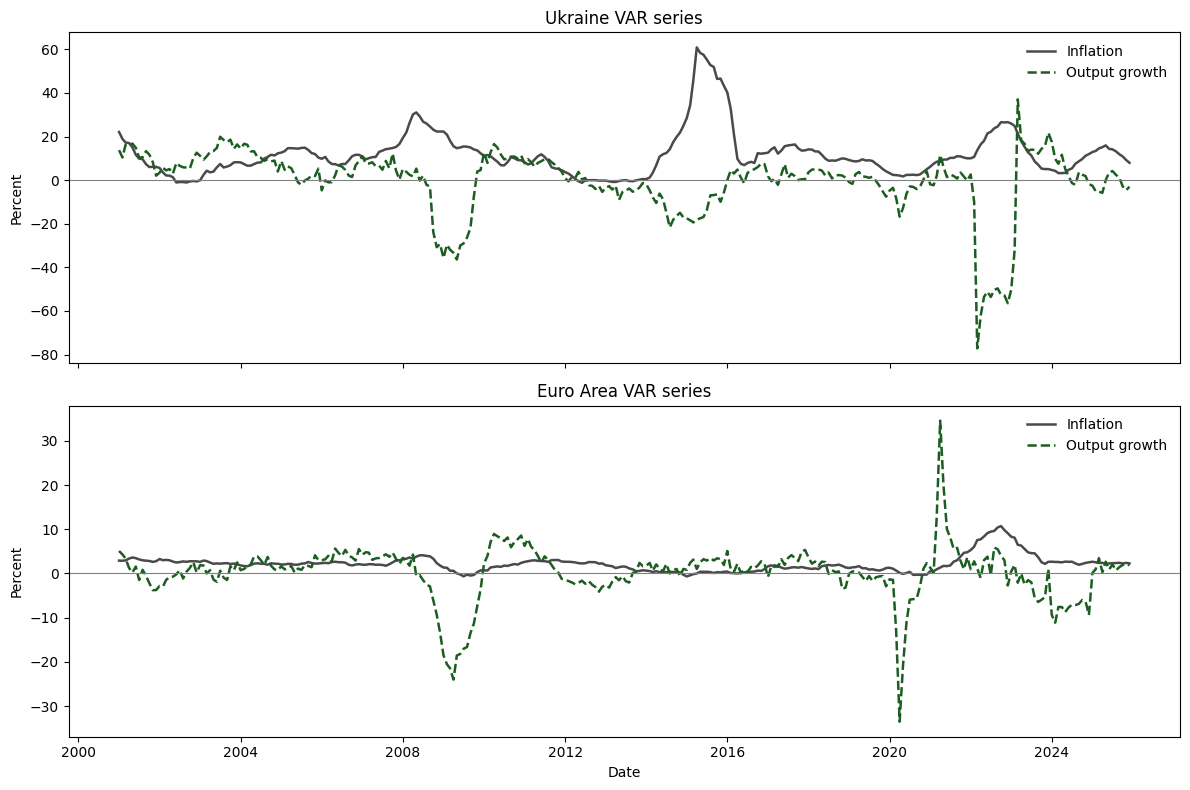

In [83]:
# inflation and IP ukraine-ea graph
plt.style.use("default")

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True, facecolor="white")
axes[0].set_facecolor("white")
axes[1].set_facecolor("white")

inflation_color = "#4A4A4A"
output_color = "#1B5E20"

# Ukraine
axes[0].plot(
    ukr_var_df["date"],
    ukr_var_df["ukraine_inflation_yoy"],
    label="Inflation",
    color=inflation_color,
    linewidth=1.8
)
axes[0].plot(
    ukr_var_df["date"],
    ukr_var_df["ukraine_ip_yoy"],
    label="Output growth",
    color=output_color,
    linewidth=1.8,
    linestyle="--"
)
axes[0].axhline(0, color="gray", linewidth=0.8)
axes[0].set_title("Ukraine VAR series", fontsize=12)
axes[0].set_ylabel("Percent")
axes[0].legend(frameon=False, loc="upper right")

# Euro Area
axes[1].plot(
    ea_var_df["date"],
    ea_var_df["euro_area_inflation_yoy"],
    label="Inflation",
    color=inflation_color,
    linewidth=1.8
)
axes[1].plot(
    ea_var_df["date"],
    ea_var_df["euro_area_ip_yoy"],
    label="Output growth",
    color=output_color,
    linewidth=1.8,
    linestyle="--"
)
axes[1].axhline(0, color="gray", linewidth=0.8)
axes[1].set_title("Euro Area VAR series", fontsize=12)
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Percent")
axes[1].legend(frameon=False, loc="upper right")

plt.tight_layout()
plt.show()


In [84]:
# now we can do some basic checks on the stationarity of the series using the Augmented Dickey-Fuller test
#null hipothesis: the series has a unit root,is non-stationary. alternative hypothesis: the series is stationary
from statsmodels.tsa.stattools import adfuller

def adf_check(series, name):
    result = adfuller(series.dropna(), autolag="AIC")
    
    print(name)
    print("ADF statistic:", result[0])
    print("p-value:", result[1])
    print("used lags:", result[2])
    print("n obs:", result[3])
    print("critical values:", result[4])
    print("")

adf_check(ukr_var_df["ukraine_inflation_yoy"], "Ukraine inflation")
adf_check(ukr_var_df["ukraine_ip_yoy"], "Ukraine output growth")

adf_check(ea_var_df["euro_area_inflation_yoy"], "Euro Area inflation")
adf_check(ea_var_df["euro_area_ip_yoy"], "Euro Area output growth")
adf_check(ukr_var_df["oil_yoy"], "Oil yoy")
# if the p-value is below 0.05, I reject the null of a unit root so the series looks stationary in the ADF test
# this is only a quick check before the VAR
# I do not want to over-interpret one test, especially with crisis episodes and possible breaks
# in general, yoy inflation and yoy output growth are more plausible in a VAR than level series
# but I still check them explicitly instead of assuming stationarity
# Ukraine inflation and Euro Area output growth look stationary, while Ukraine output growth and Euro Area inflation do not reject the unit root null at usual levels, so stationarity is mixed and this is something to keep in mind before estimating the VAR.
# oil yoy looks stationary, which is good if I want to use it as an exogenous variable in the VAR.


Ukraine inflation
ADF statistic: -3.334638443043776
p-value: 0.013399373583921603
used lags: 13
n obs: 286
critical values: {'1%': np.float64(-3.4534232986669546), '5%': np.float64(-2.8716994185534745), '10%': np.float64(-2.5721833625116144)}

Ukraine output growth
ADF statistic: -3.504086909251757
p-value: 0.007882751840634188
used lags: 13
n obs: 286
critical values: {'1%': np.float64(-3.4534232986669546), '5%': np.float64(-2.8716994185534745), '10%': np.float64(-2.5721833625116144)}

Euro Area inflation
ADF statistic: -2.5783168268294188
p-value: 0.09756205859007006
used lags: 12
n obs: 287
critical values: {'1%': np.float64(-3.453342167806272), '5%': np.float64(-2.871663828287282), '10%': np.float64(-2.572164381381345)}

Euro Area output growth
ADF statistic: -3.7673817505127025
p-value: 0.0032592391273007838
used lags: 16
n obs: 283
critical values: {'1%': np.float64(-3.453670163592738), '5%': np.float64(-2.8718077069772248), '10%': np.float64(-2.5722411158835796)}

Oil yoy
ADF st

In [85]:
# now we can also do the KPSS test, null hypothesis : the series is stationary so here a large p-value is good, unlike ADF
from statsmodels.tsa.stattools import kpss


def kpss_check(series, name):
    result = kpss(series.dropna(), regression="c", nlags="auto")
    
    print(name)
    print("KPSS statistic:", result[0])
    print("p-value:", result[1])
    print("used lags:", result[2])
    print("critical values:", result[3])
    print("")

kpss_check(ukr_var_df["ukraine_inflation_yoy"], "Ukraine inflation")
kpss_check(ukr_var_df["ukraine_ip_yoy"], "Ukraine output growth")

kpss_check(ea_var_df["euro_area_inflation_yoy"], "Euro Area inflation")
kpss_check(ea_var_df["euro_area_ip_yoy"], "Euro Area output growth")
# p value is above 0.05 for ukraine inflation (stationary) and euro area output growth (stationary), confirming the ADF results. For the other two series, we have mixed results because euro inflation was non stationary and with kpss is stationary and  still  ukraine outpout is non stationary.


Ukraine inflation
KPSS statistic: 0.09912757376664508
p-value: 0.1
used lags: 10
critical values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}

Ukraine output growth
KPSS statistic: 0.428392732511233
p-value: 0.06491692564170992
used lags: 10
critical values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}

Euro Area inflation
KPSS statistic: 0.24326586877333625
p-value: 0.1
used lags: 10
critical values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}

Euro Area output growth
KPSS statistic: 0.052922170653136286
p-value: 0.1
used lags: 10
critical values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}



C:\Users\mgmorenogonz\AppData\Local\Temp\ipykernel_15188\2026876165.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series.dropna(), regression="c", nlags="auto")
C:\Users\mgmorenogonz\AppData\Local\Temp\ipykernel_15188\2026876165.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series.dropna(), regression="c", nlags="auto")
C:\Users\mgmorenogonz\AppData\Local\Temp\ipykernel_15188\2026876165.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series.dropna(), regression="c", nlags="auto")


ukraine growth has big shocks so stationarity is not that clean because of the persistence and structural breaks.


In [86]:
from statsmodels.tsa.api import VAR

# for the VAR I keep the economic order:
# 1. output growth
# 2. inflation
# this will matter later when I think about identification
ukr_var_data = ukr_var_df[["ukraine_ip_yoy", "ukraine_inflation_yoy"]].copy()
ea_var_data = ea_var_df[["euro_area_ip_yoy", "euro_area_inflation_yoy"]].copy()

# oil is not part of the core endogenous block
# I keep it separately and use it as an exogenous control
ukr_exog = ukr_var_df[["oil_yoy"]].copy()
ea_exog = ea_var_df[["oil_yoy"]].copy()

# create the reduced-form VAR objects
ukr_model = VAR(ukr_var_data, exog=ukr_exog)
ea_model = VAR(ea_var_data, exog=ea_exog)

# try lag lengths from 0 up to 12 months 
ukr_lag_order = ukr_model.select_order(maxlags=12)
ea_lag_order = ea_model.select_order(maxlags=12)

# show the information criteria for each possible lag length
print("Ukraine lag selection")
print(ukr_lag_order.summary())

print("Euro Area lag selection")
print(ea_lag_order.summary())


Ukraine lag selection
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        9.916       9.967   2.025e+04       9.936
1        5.268       5.370       194.0       5.309
2       4.763*      4.916*      117.1*      4.824*
3        4.787       4.991       120.0       4.869
4        4.813       5.067       123.1       4.915
5        4.820       5.126       124.0       4.943
6        4.835       5.191       125.9       4.978
7        4.839       5.246       126.4       5.002
8        4.825       5.283       124.6       5.008
9        4.847       5.356       127.5       5.051
10       4.821       5.381       124.2       5.045
11       4.806       5.417       122.4       5.051
12       4.827       5.489       125.0       5.092
--------------------------------------------------
Euro Area lag selection
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE  

In [87]:
# initial benchmark VAR with 2 lags for both systems
# I later keep 2 lags for Ukraine but increase Euro Area lags
# because residual autocorrelation remains in the shorter specification
p_ukr = 2
p_ea = 2

ukr_var = ukr_model.fit(p_ukr)
ea_var = ea_model.fit(p_ea)

print(ukr_var.summary())
print(ea_var.summary())

# I do not read these coefficients as structural causal effects because each equation just regresses one variable on its own lags and the lags of the other one
# the main point of the VAR is the dynamic system behind it, especially IRFs and later the structural decomposition


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 01, May, 2026
Time:                     14:56:40
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                    4.86991
Nobs:                     298.000    HQIC:                   4.78063
Log likelihood:          -1537.12    FPE:                    112.286
AIC:                      4.72104    Det(Omega_mle):         107.897
--------------------------------------------------------------------
Results for equation ukraine_ip_yoy
                              coefficient       std. error           t-stat            prob
-------------------------------------------------------------------------------------------
const                           -0.070842         0.631550           -0.112           0.911
oil_yoy                         -0.000189         0.012277           -0.015           0.988
L1.ukra

In this VAR summary, each coefficient shows how the current endogenous variable is related to its own lags and to the lags of the other endogenous variable, conditional on the rest of the system and on the exogenous oil control. For example, the coefficient on L1.ukraine_ip_yoy is 0.9543. This means that current Ukraine industrial production growth is still strongly related to its own previous month value, even after controlling for the other lagged terms in the VAR and for oil_yoy as an exogenous variable. The coefficient is highly significant, which points to strong short-run persistence. 

In [88]:
#Stability condition. our VAR is stable if the roots lies outside the unit circle
print(ukr_var.roots)
print("Ukraine", np.all(np.abs(ukr_var.roots) > 1))

print(ea_var.roots)
print("Euro Area", np.all(np.abs(ea_var.roots) > 1))


[13.25680848-0.j          1.38474548-0.j          1.14482522+0.01570364j
  1.14482522-0.01570364j]
Ukraine True
[9.48535613 3.99936134 1.3739144  1.04968705]
Euro Area True


In [89]:
# ukraine
print(sum(np.abs(ukr_var.roots) <= 1))

# euro area
print(sum(np.abs(ea_var.roots) <= 1))
# both VARs are stable, as all roots lie outside the unit circle. This means that shocks to the system will eventually die out and not lead to explosive behavior :)


0
0


In [90]:
#autocorrelation
# ukraine
print(ukr_var.test_whiteness())

# euro area
print(ea_var.test_whiteness())
# P value above 0.05 means that we failed to disprove the null hypothesis  where the null hypothesis presents correlation equal to zero and p value is above 0.05 for ukraine and not for eu 


<statsmodels.tsa.vector_ar.hypothesis_test_results.WhitenessTestResults object. H_0: residual autocorrelation up to lag 10 is zero: fail to reject at 5% significance level. Test statistic: 34.605, critical value: 46.194>, p-value: 0.345>
<statsmodels.tsa.vector_ar.hypothesis_test_results.WhitenessTestResults object. H_0: residual autocorrelation up to lag 10 is zero: reject at 5% significance level. Test statistic: 114.571, critical value: 46.194>, p-value: 0.000>


There is remaining dynamic in data that models is not taking into account for EA

In [91]:
# final VAR specification used below
# Ukraine: 2 lags are enough according to the whiteness test
# Euro Area: I use 8 lags because it greatly reduces residual autocorrelation,
# even if some residual dependence still remains
p_ukr = 2
p_ea = 8

ukr_var = ukr_model.fit(p_ukr)
ea_var = ea_model.fit(p_ea)

print(ukr_var.test_whiteness())
print(ea_var.test_whiteness())


<statsmodels.tsa.vector_ar.hypothesis_test_results.WhitenessTestResults object. H_0: residual autocorrelation up to lag 10 is zero: fail to reject at 5% significance level. Test statistic: 34.605, critical value: 46.194>, p-value: 0.345>
<statsmodels.tsa.vector_ar.hypothesis_test_results.WhitenessTestResults object. H_0: residual autocorrelation up to lag 10 is zero: reject at 5% significance level. Test statistic: 44.741, critical value: 15.507>, p-value: 0.000>


In [92]:
#normality 
# ukraine
print(ukr_var.test_normality())

# euro area
print(ea_var.test_normality())
# a p-value above 0.05 means I do not reject normality
# here both p-values are essentially zero, so I reject normality for both systems
# this is not surprising in macro monthly data with crises, large shocks, and structural breaks


<statsmodels.tsa.vector_ar.hypothesis_test_results.NormalityTestResults object. H_0: data generated by normally-distributed process: reject at 5% significance level. Test statistic: 50040.015, critical value: 9.488>, p-value: 0.000>
<statsmodels.tsa.vector_ar.hypothesis_test_results.NormalityTestResults object. H_0: data generated by normally-distributed process: reject at 5% significance level. Test statistic: 2723.376, critical value: 9.488>, p-value: 0.000>


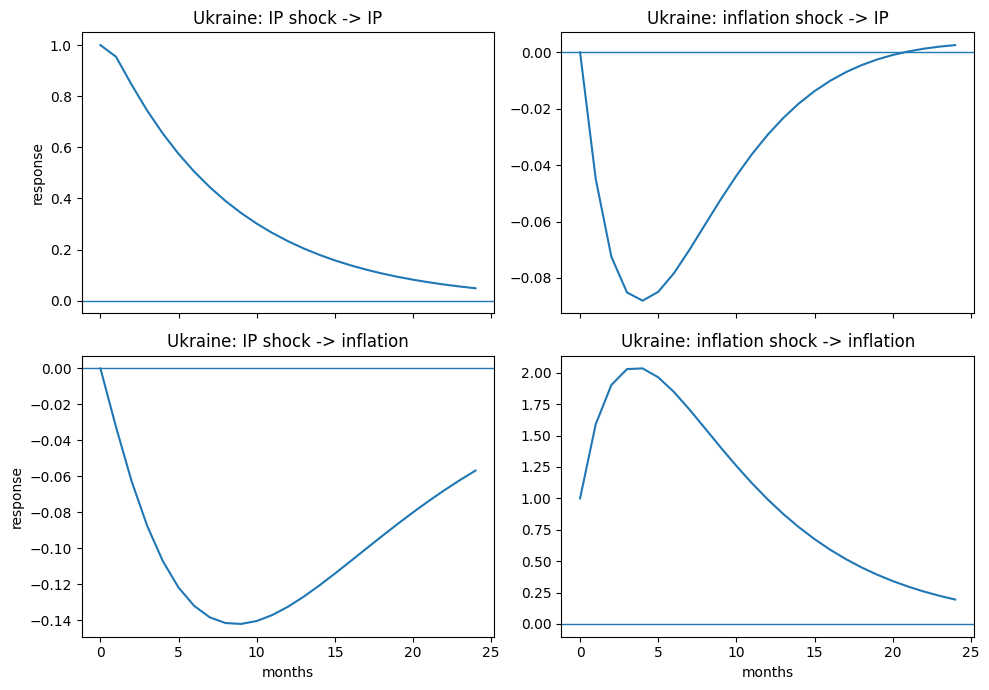

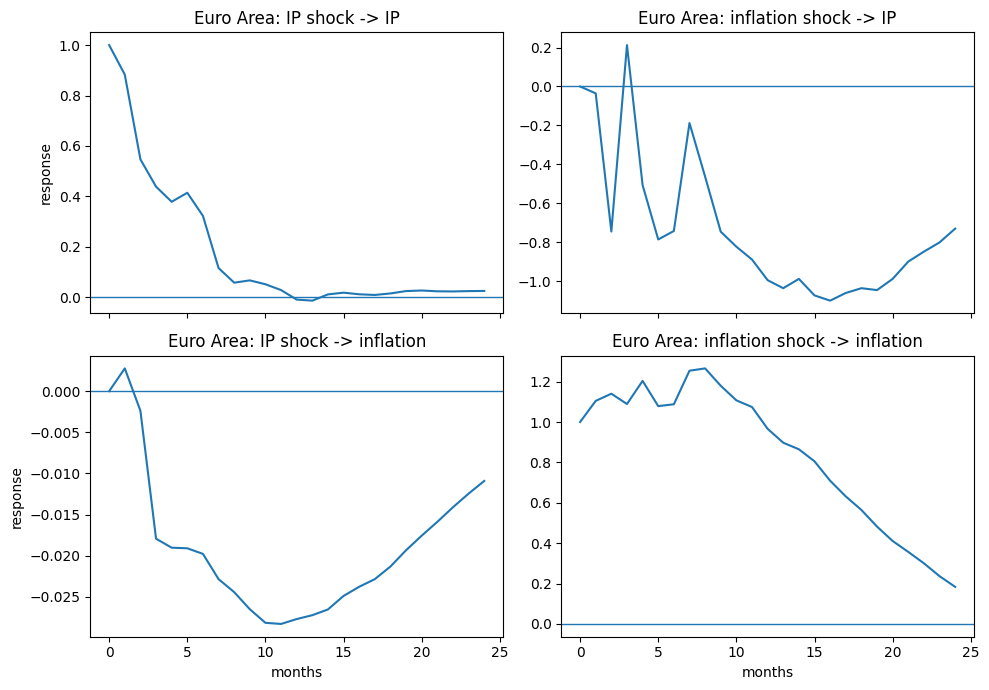

In [93]:
# reduced-form impulse responses
# still just a first look, but plotted more cleanly

ukr_irf = ukr_var.irf(24)
ea_irf = ea_var.irf(24)

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True)
h = np.arange(25)

# Ukraine: shock to output growth
axes[0, 0].plot(h, ukr_irf.irfs[:, 0, 0])
axes[0, 0].axhline(0, linewidth=1)
axes[0, 0].set_title("Ukraine: IP shock -> IP")
axes[0, 0].set_ylabel("response")

axes[0, 1].plot(h, ukr_irf.irfs[:, 0, 1])
axes[0, 1].axhline(0, linewidth=1)
axes[0, 1].set_title("Ukraine: inflation shock -> IP")
# to inflation
axes[1, 0].plot(h, ukr_irf.irfs[:, 1, 0])
axes[1, 0].axhline(0, linewidth=1)
axes[1, 0].set_title("Ukraine: IP shock -> inflation")
axes[1, 0].set_xlabel("months")
axes[1, 0].set_ylabel("response")

axes[1, 1].plot(h, ukr_irf.irfs[:, 1, 1])
axes[1, 1].axhline(0, linewidth=1)
axes[1, 1].set_title("Ukraine: inflation shock -> inflation")
axes[1, 1].set_xlabel("months")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True)
h = np.arange(25)

# Euro Area: shock to output growth
axes[0, 0].plot(h, ea_irf.irfs[:, 0, 0])
axes[0, 0].axhline(0, linewidth=1)
axes[0, 0].set_title("Euro Area: IP shock -> IP")
axes[0, 0].set_ylabel("response")

axes[0, 1].plot(h, ea_irf.irfs[:, 0, 1])
axes[0, 1].axhline(0, linewidth=1)
axes[0, 1].set_title("Euro Area: inflation shock -> IP")
#inflation
axes[1, 0].plot(h, ea_irf.irfs[:, 1, 0])
axes[1, 0].axhline(0, linewidth=1)
axes[1, 0].set_title("Euro Area: IP shock -> inflation")
axes[1, 0].set_xlabel("months")
axes[1, 0].set_ylabel("response")

axes[1, 1].plot(h, ea_irf.irfs[:, 1, 1])
axes[1, 1].axhline(0, linewidth=1)
axes[1, 1].set_title("Euro Area: inflation shock -> inflation")
axes[1, 1].set_xlabel("months")

plt.tight_layout()
plt.show()


here we are not impossing any restriction that separate the shocks. 

In [94]:
# build the long-run reduced-form matrix for Ukraine
# A1, A2, ..., Ap from the fitted VAR
A_ukr = ukr_var.coefs

# identity matrix with the size of the endogenous block
I_ukr = np.eye(A_ukr.shape[1])

# sum of autoregressive coefficient matrices
A_ukr_sum = A_ukr.sum(axis=0)

# long-run reduced-form multiplier
# this gives the cumulative effect of reduced-form shocks on the system
LR_ukr = np.linalg.inv(I_ukr - A_ukr_sum)

print("Ukraine long-run matrix")
print(LR_ukr)


Ukraine long-run matrix
[[ 8.91416824 -0.75911697]
 [-2.98891853 27.23021717]]


In [95]:
# build the long-run reduced-form matrix for the Euro Area

# A1, A2, ..., Ap from the fitted VAR
A_ea = ea_var.coefs

# identity matrix with the size of the endogenous block
I_ea = np.eye(A_ea.shape[1])

# sum of autoregressive coefficient matrices
A_ea_sum = A_ea.sum(axis=0)

# long-run reduced-form multiplier
# this gives the cumulative effect of reduced-form shocks on the system
LR_ea = np.linalg.inv(I_ea - A_ea_sum)

print("Euro Area long-run matrix")
print(LR_ea)
# rows = responses, columns = reduced-form shocks
# row 1: output growth
# row 2: inflation


Euro Area long-run matrix
[[  4.62778233 -20.54597871]
 [ -0.46472793  19.39401904]]


In [96]:
# reduced-form residual covariance matrix
# this tells me how the reduced-form residuals move together
Omega_ukr = np.cov(ukr_var.resid.T, ddof=1)

print("Ukraine Omega")
print(Omega_ukr)

# long-run covariance matrix of reduced-form shocks
S_ukr = LR_ukr @ Omega_ukr @ LR_ukr.T

print("Ukraine long-run covariance")
print(S_ukr)

# lower-triangular long-run impact matrix
# this is the Blanchard-Quah step:
# with the ordering [output growth, inflation], shock 2 has no long-run effect on output growth
C_ukr = np.linalg.cholesky(S_ukr)

print("Ukraine long-run structural impact matrix")
print(C_ukr)

# recover the contemporaneous structural impact matrix B
# this maps structural shocks into reduced-form innovations
B_ukr = np.linalg.inv(LR_ukr) @ C_ukr

print("Ukraine B matrix")
print(B_ukr)

# check: LR @ B should reproduce the long-run structural matrix
print("LR and B")
print(LR_ukr @ B_ukr)


Ukraine Omega
[[44.46962056 -1.63323895]
 [-1.63323895  2.40529337]]
Ukraine long-run covariance
[[ 3557.15256187 -1634.70540738]
 [-1634.70540738  2446.61865857]]
Ukraine long-run structural impact matrix
[[ 59.6418692    0.        ]
 [-27.40868838  41.17502228]]
Ukraine B matrix
[[ 6.66728766  0.1299838 ]
 [-0.27472086  1.52637539]]
LR and B
[[ 5.96418692e+01 -1.47089952e-16]
 [-2.74086884e+01  4.11750223e+01]]


In [97]:
# reduced-form residual covariance matrix
# this tells me how the reduced-form residuals move together
Omega_ea = np.cov(ea_var.resid.T, ddof=1)
print("Euro Area Omega")
print(Omega_ea)

# long-run covariance matrix of reduced-form shocks
S_ea = LR_ea @ Omega_ea @ LR_ea.T

print("Euro Area long-run covariance")
print(S_ea)

# lower-triangular long-run impact matrix
# this is the Blanchard-Quah step:
# with the ordering [output growth, inflation], shock 2 has no long-run effect on output growth
C_ea = np.linalg.cholesky(S_ea)

print("Euro Area long-run structural impact matrix")
print(C_ea)

# recover the contemporaneous structural impact matrix B
# this maps structural shocks into reduced-form innovations
B_ea = np.linalg.inv(LR_ea) @ C_ea

print("Euro Area B matrix")
print(B_ea)

# check: LR @ B should reproduce the long-run structural matrix
print("LR and B")
print(LR_ea @ B_ea)


Euro Area Omega
[[7.57491941 0.0315081 ]
 [0.0315081  0.06571922]]
Euro Area long-run covariance
[[183.97807632 -39.34941188]
 [-39.34941188  25.78684749]]
Euro Area long-run structural impact matrix
[[13.56385182  0.        ]
 [-2.90104997  4.16782396]]
Euro Area B matrix
[[ 2.53672142  1.0676909 ]
 [-0.08879875  0.24048701]]
LR and B
[[ 1.35638518e+01 -1.87412378e-16]
 [-2.90104997e+00  4.16782396e+00]]


Under this identification, the first structural shock is interpreted as a supply shock, while the second one is interpreted as a demand shock.

The model does not know from the start which shock is supply and which one is demand.  
This distinction comes from the restriction we impose. In our case, the second shock is restricted to have no long-run effect on output.

Therefore, the shock that is allowed to change output permanently is interpreted as the **supply shock**, while the shock that can affect output only temporarily is interpreted as the demand shock.

 *“A demand shock has no long-run effect on the level of GDP.”*

The reduced-form VAR residuals are denoted by $u_t$.

After structural identification, these residuals can be written as:

$$
u_t = B \varepsilon_t
$$

where $u_t$ are the reduced-form innovations, $B$ is the contemporaneous impact matrix, and $\varepsilon_t$ are the structural shocks.

Once $B$ is identified, the structural shocks can be recovered as:

$$
\varepsilon_t = B^{-1} u_t
$$

At each date, this gives two structural shocks:

- the first one is interpreted as a supply shock  
- the second one is interpreted as a demand shock

In [98]:
# reduced-form residuals from the Ukraine VAR
U_ukr = ukr_var.resid.copy()
U_ukr.columns = ["u_output", "u_inflation"]

# recover structural shocks using eps_t = B^{-1} u_t
# shock 1 = supply shock
# shock 2 = demand shock
eps_ukr = pd.DataFrame(
    np.asarray((np.linalg.inv(B_ukr) @ U_ukr.T).T),
    index=U_ukr.index,
    columns=["supply_shock_ukr", "demand_shock_ukr"]
)

print(eps_ukr.head())
print(eps_ukr.tail())
print(eps_ukr.describe())


   supply_shock_ukr  demand_shock_ukr
2          1.086949          0.668549
3          0.178664          0.904286
4          0.408895         -0.838517
5          0.018456         -1.205082
6         -0.414193          0.280713
     supply_shock_ukr  demand_shock_ukr
295         -0.172582         -0.409370
296         -0.118698         -0.475554
297         -0.552471         -0.180046
298         -0.246038         -0.782382
299          0.183470         -0.241073
       supply_shock_ukr  demand_shock_ukr
count      2.980000e+02      2.980000e+02
mean       5.960929e-17      1.676511e-15
std        1.000000e+00      1.000000e+00
min       -1.009304e+01     -6.713826e+00
25%       -2.706284e-01     -4.055679e-01
50%        4.542525e-03     -6.892791e-02
75%        3.282833e-01      3.931746e-01
max        9.616560e+00      5.925398e+00


In [99]:
# reduced-form residuals from the Euro Area VAR
U_ea = ea_var.resid.copy()
U_ea.columns = ["u_output", "u_inflation"]

# recover structural shocks using eps_t = B^{-1} u_t
# shock 1 = supply shock
# shock 2 = demand shock
eps_ea = pd.DataFrame(
    np.asarray((np.linalg.inv(B_ea) @ U_ea.T).T),
    index=U_ea.index,
    columns=["supply_shock_ea", "demand_shock_ea"]
)

print(eps_ea.head())
print(eps_ea.tail())
print(eps_ea.describe())


    supply_shock_ea  demand_shock_ea
8         -0.274468         0.370619
9         -0.052948         0.568975
10        -0.257814        -0.013795
11        -0.236447         1.076437
12        -0.659948         2.548906
     supply_shock_ea  demand_shock_ea
295        -0.120492         0.339365
296         0.352310         0.812960
297         0.562208        -0.056993
298         0.076316         1.036730
299         0.289825         0.232639
       supply_shock_ea  demand_shock_ea
count     2.920000e+02     2.920000e+02
mean     -1.453936e-15     2.007527e-15
std       1.000000e+00     1.000000e+00
min      -6.347841e+00    -3.534488e+00
25%      -4.573888e-01    -5.489727e-01
50%       3.425365e-02    -5.545870e-02
75%       4.590395e-01     5.009142e-01
max       6.484200e+00     3.850148e+00


This step recovers the structural shocks from the reduced-form VAR residuals.  
The reduced-form residuals are statistical innovations, but they do not yet correspond to pure economic shocks. 

In [100]:
ukr_dates = ukr_var_df["date"].iloc[p_ukr:].reset_index(drop=True)
eps_ukr = eps_ukr.reset_index(drop=True)
eps_ukr["date"] = ukr_dates


In [101]:
ea_dates = ea_var_df["date"].iloc[p_ea:].reset_index(drop=True)
eps_ea = eps_ea.reset_index(drop=True)
eps_ea["date"] = ea_dates


In [102]:
# keep only the common sample of structural shocks
# this matters because the two systems lose a different number of initial observations
shocks_df = pd.merge(
    eps_ukr,
    eps_ea,
    on="date",
    how="inner"
).sort_values("date").reset_index(drop=True)

print(shocks_df.head())
print(shocks_df.tail())
print(shocks_df["date"].min(), shocks_df["date"].max())
print(len(shocks_df))


   supply_shock_ukr  demand_shock_ukr       date  supply_shock_ea  \
0          0.639989         -1.271409 2001-09-01        -0.274468   
1         -0.053897          0.199027 2001-10-01        -0.052948   
2         -0.305744          0.516169 2001-11-01        -0.257814   
3         -0.736517         -0.259291 2001-12-01        -0.236447   
4          0.327258         -0.454749 2002-01-01        -0.659948   

   demand_shock_ea  
0         0.370619  
1         0.568975  
2        -0.013795  
3         1.076437  
4         2.548906  
     supply_shock_ukr  demand_shock_ukr       date  supply_shock_ea  \
287         -0.172582         -0.409370 2025-08-01        -0.120492   
288         -0.118698         -0.475554 2025-09-01         0.352310   
289         -0.552471         -0.180046 2025-10-01         0.562208   
290         -0.246038         -0.782382 2025-11-01         0.076316   
291          0.183470         -0.241073 2025-12-01         0.289825   

     demand_shock_ea  
287      

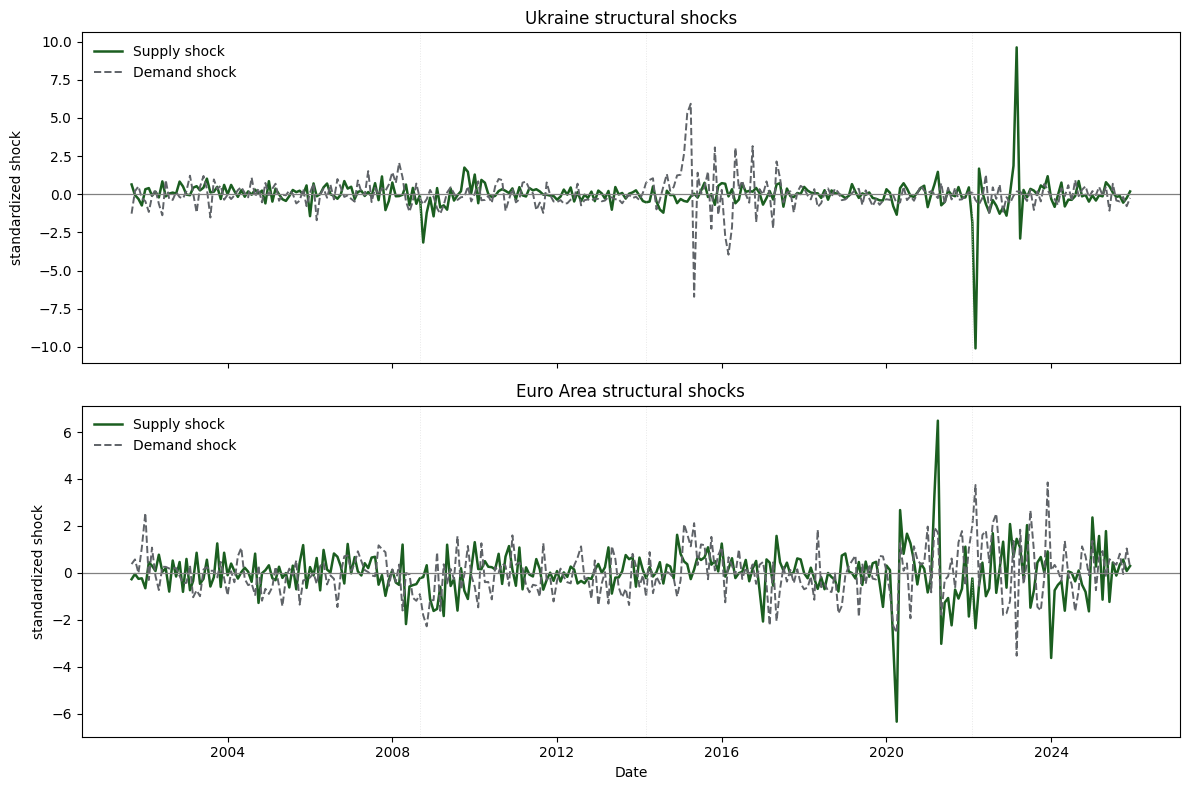

In [103]:
plt.style.use("default")

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# crisis dates
crisis_dates = [
    "2008-09-01",
    "2014-03-01",
    "2022-02-01"
]

# colors
supply_color = "#1B5E20"
demand_color = "#5F6368"
crisis_color = "#D9D9D9"

# Ukraine
axes[0].plot(
    shocks_df["date"],
    shocks_df["supply_shock_ukr"],
    label="Supply shock",
    color=supply_color,
    linewidth=1.8
)
axes[0].plot(
    shocks_df["date"],
    shocks_df["demand_shock_ukr"],
    label="Demand shock",
    color=demand_color,
    linewidth=1.4,
    linestyle="--"
)
axes[0].axhline(0, color="gray", linewidth=0.9)

for d in crisis_dates:
    axes[0].axvline(
        pd.to_datetime(d),
        color=crisis_color,
        linestyle=":",
        linewidth=0.7,
        alpha=0.6
    )

axes[0].set_title("Ukraine structural shocks", fontsize=12)
axes[0].set_ylabel("standardized shock")
axes[0].legend(frameon=False, loc="upper left")

# Euro Area
axes[1].plot(
    shocks_df["date"],
    shocks_df["supply_shock_ea"],
    label="Supply shock",
    color=supply_color,
    linewidth=1.8
)
axes[1].plot(
    shocks_df["date"],
    shocks_df["demand_shock_ea"],
    label="Demand shock",
    color=demand_color,
    linewidth=1.4,
    linestyle="--"
)
axes[1].axhline(0, color="gray", linewidth=0.9)

for d in crisis_dates:
    axes[1].axvline(
        pd.to_datetime(d),
        color=crisis_color,
        linestyle=":",
        linewidth=0.7,
        alpha=0.6
    )

axes[1].set_title("Euro Area structural shocks", fontsize=12)
axes[1].set_ylabel("standardized shock")
axes[1].set_xlabel("Date")
axes[1].legend(frameon=False, loc="upper left")

plt.tight_layout()
plt.show()


### Benchmark counterfactual shocks
Main specification: Ukraine keeps its own supply shocks and receives Euro Area demand shocks with regime-based treatment intensity.



The counterfactual does not assume that euro membership would have affected Ukraine in the same way at all dates. I  use a regime-based treatment intensity, considering  Part A.

The weight is higher during large devaluation episodes and during the inflation-targeting period, when Ukraine had more effective monetary autonomy. It is lower during peg or wartime-control periods, when monetary sovereignty was already constrained. These weights are a calibration, not estimated parameters, and are used to translate the qualitative regime chronology into the shock-replacement exercise.

In [104]:
# counterfactual shocks with time-varying treatment intensity
# baseline calibration:
# - Ukraine always keeps its own supply shocks
# - demand shocks are partially replaced depending on the monetary regime

shocks_cf = shocks_df.copy()

# supply side remains Ukrainian
shocks_cf["supply_shock_cf"] = shocks_cf["supply_shock_ukr"]

# default: start from Ukraine demand shocks
shocks_cf["treatment_weight"] = 0.0

# 2001-2007:
# constrained regime, but still a  gap relative to the euro
shocks_cf.loc[
    (shocks_cf["date"] >= "2001-09-01") &
    (shocks_cf["date"] <= "2007-12-01"),
    "treatment_weight"
] = 0.6

# early 2008 before the large crisis break
shocks_cf.loc[
    (shocks_cf["date"] >= "2008-01-01") &
    (shocks_cf["date"] <= "2008-08-01"),
    "treatment_weight"
] = 0.5

# 2008-2009 crisis and large devaluation:
# euro membership would likely have changed the adjustment much more
shocks_cf.loc[
    (shocks_cf["date"] >= "2008-09-01") &
    (shocks_cf["date"] <= "2009-12-01"),
    "treatment_weight"
] = 1.0

# 2010-2013 constrained regime again:
# still low sovereignty, but not zero credibility gains from the euro
shocks_cf.loc[
    (shocks_cf["date"] >= "2010-01-01") &
    (shocks_cf["date"] <= "2013-12-01"),
    "treatment_weight"
] = 0.4

# 2014-2015 major devaluation episode:
# here the euro counterfactual should matter a lot
shocks_cf.loc[
    (shocks_cf["date"] >= "2014-02-01") &
    (shocks_cf["date"] <= "2015-12-01"),
    "treatment_weight"
] = 1.0

# 2016-2021 inflation targeting:
# more autonomy than before, but smaller credibility gap than pre-2016
shocks_cf.loc[
    (shocks_cf["date"] >= "2016-01-01") &
    (shocks_cf["date"] <= "2021-12-01"),
    "treatment_weight"
] = 0.6

# wartime peg:
# very compressed monetary sovereignty
shocks_cf.loc[
    (shocks_cf["date"] >= "2022-01-01") &
    (shocks_cf["date"] <= "2023-07-01"),
    "treatment_weight"
] = 0.1

# late 2023 transition:
# some flexibility returns, but not a full normal regime
shocks_cf.loc[
    (shocks_cf["date"] >= "2023-08-01"),
    "treatment_weight"
] = 0.2

# demand shock under the counterfactual
shocks_cf["demand_shock_cf"] = (
    (1 - shocks_cf["treatment_weight"]) * shocks_cf["demand_shock_ukr"]
    + shocks_cf["treatment_weight"] * shocks_cf["demand_shock_ea"]
)


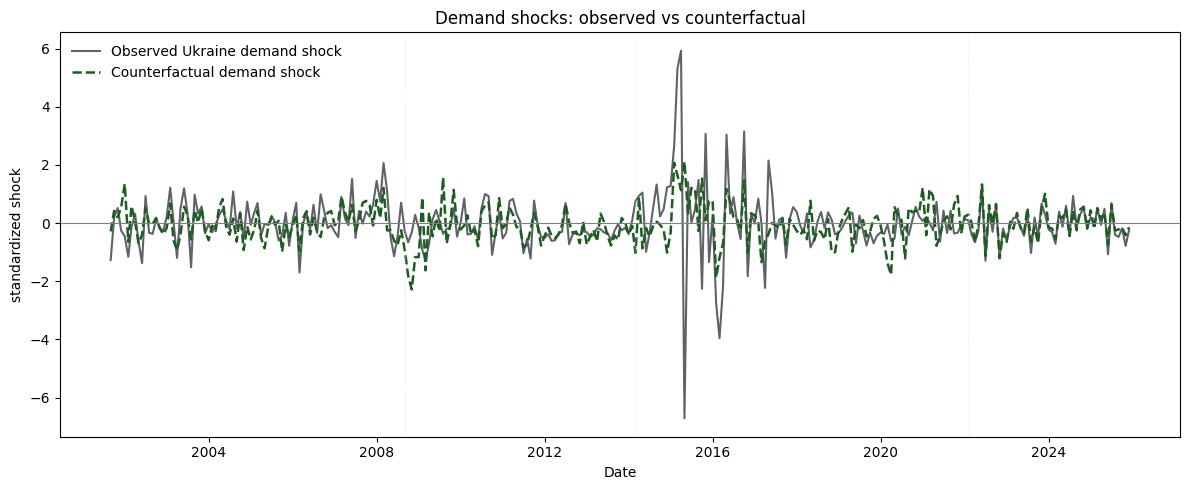

In [105]:
plt.style.use("default")

plt.figure(figsize=(12, 5))

# crisis dates
crisis_dates = [
    "2008-09-01",
    "2014-03-01",
    "2022-02-01"
]

# colors consistent with previous figures
observed_color = "#5F6368"
cf_color = "#1B5E20"
crisis_color = "#D9D9D9"

plt.plot(
    shocks_cf["date"],
    shocks_cf["demand_shock_ukr"],
    label="Observed Ukraine demand shock",
    color=observed_color,
    linewidth=1.5
)

plt.plot(
    shocks_cf["date"],
    shocks_cf["demand_shock_cf"],
    label="Counterfactual demand shock",
    color=cf_color,
    linewidth=1.8,
    linestyle="--"
)

plt.axhline(0, color="gray", linewidth=0.8)

for d in crisis_dates:
    plt.axvline(
        pd.to_datetime(d),
        color=crisis_color,
        linestyle=":",
        linewidth=0.7,
        alpha=0.6
    )

plt.title("Demand shocks: observed vs counterfactual", fontsize=12)
plt.xlabel("Date")
plt.ylabel("standardized shock")
plt.legend(frameon=False, loc="upper left")

plt.tight_layout()
plt.show()


The next step is to map the counterfactual shocks into a counterfactual inflation path for Ukraine.

I keep the estimated Ukraine VAR dynamics unchanged and partially replace the structural demand shock according to the regime-based treatment intensity defined from Part A.


In [106]:
# structural impulse responses for Ukraine
# 24 months

ukr_irf = ukr_var.irf(24)

# reduced-form MA coefficients
phi_ukr = ukr_irf.irfs.copy()

# structural impulse responses
sirf_ukr = np.array([phi_ukr[h] @ B_ukr for h in range(phi_ukr.shape[0])])

print(sirf_ukr[0])
print(sirf_ukr[1])

# interpretation:
# sirf_ukr[h][0,0] = output response at horizon h to a supply shock
# sirf_ukr[h][0,1] = output response at horizon h to a demand shock
# sirf_ukr[h][1,0] = inflation response at horizon h to a supply shock
# sirf_ukr[h][1,1] = inflation response at horizon h to a demand shock


[[ 6.66728766  0.1299838 ]
 [-0.27472086  1.52637539]]
[[ 6.37549577  0.05554662]
 [-0.65401712  2.42249432]]


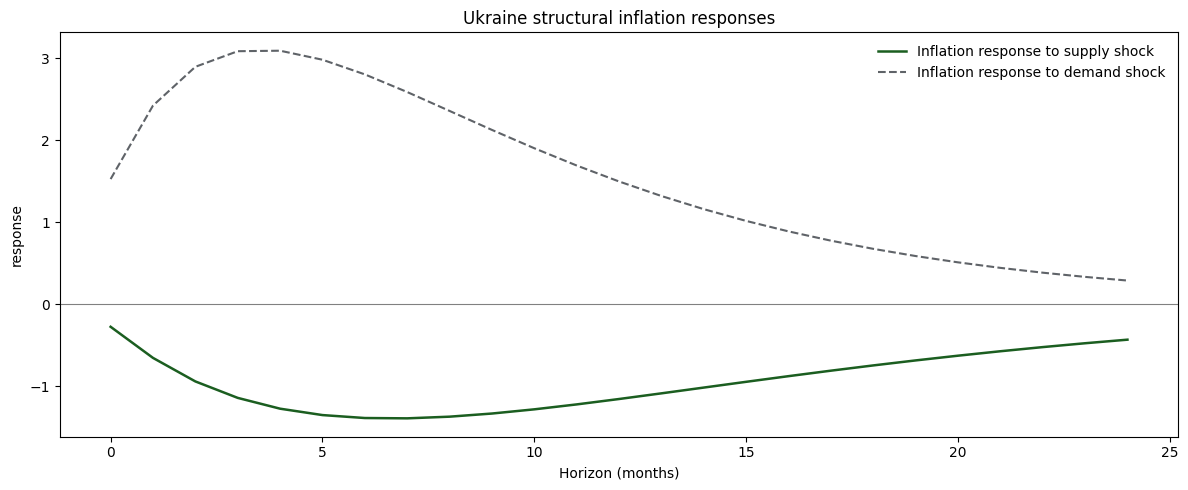

In [107]:

# responses of Ukraine inflation to the two identified structural shocks
inflation_response_to_supply = sirf_ukr[:, 1, 0]
inflation_response_to_demand = sirf_ukr[:, 1, 1]

horizons = np.arange(sirf_ukr.shape[0])

plt.style.use("default")
plt.figure(figsize=(12, 5))

supply_color = "#1B5E20"
demand_color = "#5F6368"

plt.plot(
    horizons,
    inflation_response_to_supply,
    label="Inflation response to supply shock",
    color=supply_color,
    linewidth=1.8
)

plt.plot(
    horizons,
    inflation_response_to_demand,
    label="Inflation response to demand shock",
    color=demand_color,
    linewidth=1.5,
    linestyle="--"
)

plt.axhline(0, color="gray", linewidth=0.8)

plt.title("Ukraine structural inflation responses", fontsize=12)
plt.xlabel("Horizon (months)")
plt.ylabel("response")
plt.legend(frameon=False, loc="upper right")
plt.tight_layout()
plt.show()


In [108]:
# full VAR simulation with counterfactual shocks
# the simulation uses Ukraine's VAR dynamics (constant + lags + oil) but feeds in counterfactual structural shocks instead of the observed ones
# use the raw results object
raw_ukr = ukr_var._results

# coefs[k] is the coefficient matrix at lag k+1
coefs_ukr = raw_ukr.coefs

# intercept is stored separately
intercept_ukr = raw_ukr.intercept

# coefs_exog includes both constant and oil
# column 0 matches the constant, so I only keep column 1 for oil
coef_oil_ukr = raw_ukr.coefs_exog[:, 1]

# align oil_yoy with the full sample of shocks_cf
oil_aligned = ukr_var_df.set_index("date")["oil_yoy"]

# observed Ukraine data as numpy array for initial conditions
ukr_obs = ukr_var_data.values  

# number of simulation steps
T_cf = len(shocks_cf)

# output array: rows = time, cols = [ip_yoy, inflation_yoy]
y_sim = np.zeros((T_cf + p_ukr, 2))

# initial conditions: first p_ukr observed values
y_sim[:p_ukr] = ukr_obs[:p_ukr]

for t in range(p_ukr, T_cf + p_ukr):
    idx = t - p_ukr

    # deterministic part
    y_pred = intercept_ukr.copy()

    # autoregressive part
    for k in range(p_ukr):
        y_pred += coefs_ukr[k] @ y_sim[t - 1 - k]

    # oil enters as exogenous control
    date_t = shocks_cf.iloc[idx]["date"]
    if date_t in oil_aligned.index and not np.isnan(oil_aligned.loc[date_t]):
        y_pred += coef_oil_ukr * oil_aligned.loc[date_t]

    # counterfactual structural shock -> reduced-form innovation
    eps_cf_t = np.array([
        shocks_cf.iloc[idx]["supply_shock_cf"],
        shocks_cf.iloc[idx]["demand_shock_cf"]
    ])
    u_cf_t = B_ukr @ eps_cf_t

    y_sim[t] = y_pred + u_cf_t

# extract counterfactual inflation from the simulation period only
pi_cf_full = y_sim[p_ukr:, 1]


In [109]:
# build the comparison dataframe
compare_cf = pd.DataFrame({
    "date": shocks_cf["date"].values,
    "ukraine_inflation_yoy_cf": pi_cf_full
})

compare_cf = pd.merge(
    ukr_var_df[["date", "ukraine_inflation_yoy"]],
    compare_cf,
    on="date",
    how="inner"
).sort_values("date").reset_index(drop=True)

print(compare_cf.head())

compare_cf.to_csv(TABLES_DIR / "counterfactual_baseline_series.csv", index=False)


        date  ukraine_inflation_yoy  ukraine_inflation_yoy_cf
0 2001-09-01               7.285959                 15.915121
1 2001-10-01               6.016303                 14.270690
2 2001-11-01               6.121896                 13.349994
3 2001-12-01               6.121896                 13.664096
4 2002-01-01               5.599129                 15.806463


The counterfactual inflation series is reconstructed via full VAR simulation.
Ukraine's estimated dynamics (constant, lags, oil) are preserved unchanged.
Demand shocks are partially replaced according to the regime-based treatment intensity.
Supply shocks remain Ukraine's own.


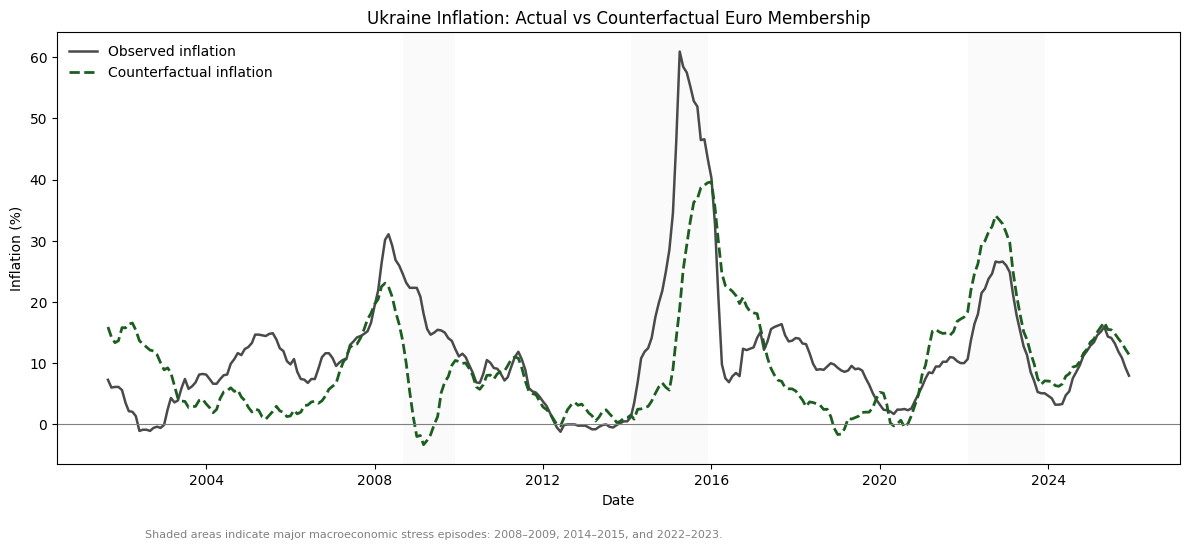

In [110]:
plt.style.use("default")

fig, ax = plt.subplots(figsize=(12, 5.5), facecolor="white")
ax.set_facecolor("white")

# colors
observed_color = "#4A4A4A"
cf_color = "#1B5E20"
shade_color = "#D9D9D9"

# shaded stress periods
ax.axvspan(
    pd.to_datetime("2008-09-01"),
    pd.to_datetime("2009-12-01"),
    color=shade_color,
    alpha=0.12,
    lw=0
)
ax.axvspan(
    pd.to_datetime("2014-02-01"),
    pd.to_datetime("2015-12-01"),
    color=shade_color,
    alpha=0.12,
    lw=0
)
ax.axvspan(
    pd.to_datetime("2022-02-01"),
    pd.to_datetime("2023-12-01"),
    color=shade_color,
    alpha=0.12,
    lw=0
)

# observed inflation
ax.plot(
    compare_cf["date"],
    compare_cf["ukraine_inflation_yoy"],
    color=observed_color,
    linewidth=1.8,
    label="Observed inflation"
)

# counterfactual inflation
ax.plot(
    compare_cf["date"],
    compare_cf["ukraine_inflation_yoy_cf"],
    color=cf_color,
    linewidth=2.0,
    linestyle="--",
    label="Counterfactual inflation"
)

# zero line
ax.axhline(0, color="gray", linewidth=0.8)

# labels and title
ax.set_title("Ukraine Inflation: Actual vs Counterfactual Euro Membership", fontsize=12)
ax.set_xlabel("Date")
ax.set_ylabel("Inflation (%)")

# legend
ax.legend(frameon=False, loc="upper left")

# small note
fig.text(
    0.125,
    0.012,
    "Shaded areas indicate major macroeconomic stress episodes: 2008–2009, 2014–2015, and 2022–2023.",
    ha="left",
    fontsize=8,
    color="gray"
)

plt.tight_layout(rect=[0, 0.04, 1, 1])
fig.savefig(FIGURES_DIR / "counterfactual_baseline.png", dpi=300, bbox_inches="tight")
plt.show()


count    292.000000
mean       2.013737
std        8.510568
min      -15.348440
25%       -2.715614
50%        0.663362
75%        7.004019
max       41.888323
Name: inflation_gap, dtype: float64


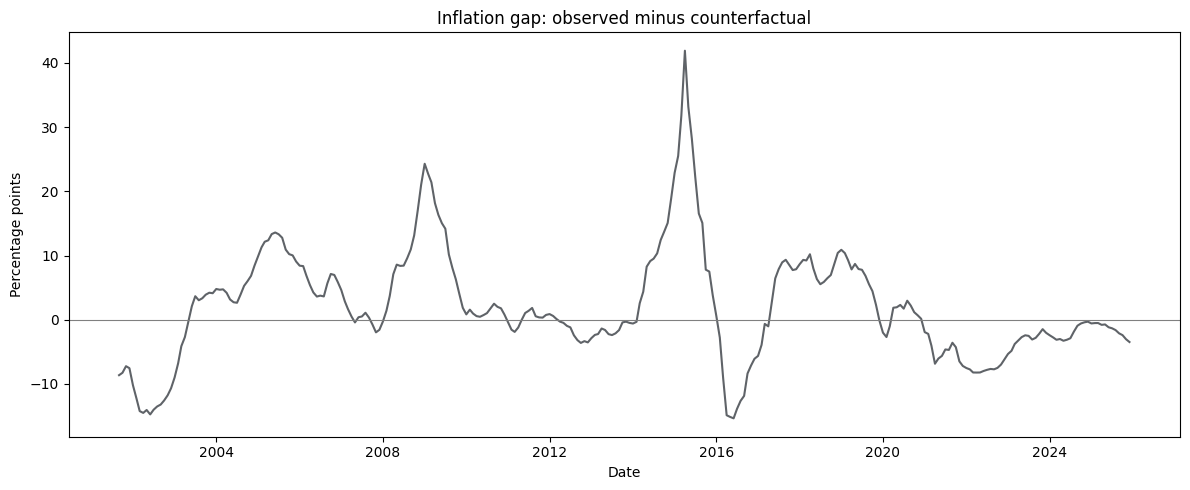

In [111]:
compare_cf["inflation_gap"] = (
    compare_cf["ukraine_inflation_yoy"] - compare_cf["ukraine_inflation_yoy_cf"]
)

print(compare_cf["inflation_gap"].describe())

plt.figure(figsize=(12, 5))
plt.plot(compare_cf["date"], compare_cf["inflation_gap"], color="#5F6368", linewidth=1.5)
plt.axhline(0, color="gray", linewidth=0.8)
plt.title("Inflation gap: observed minus counterfactual")
plt.xlabel("Date")
plt.ylabel("Percentage points")
plt.tight_layout()
plt.show()


In [112]:
# summary by key subperiods

def period_mean(df, start, end, col):
    mask = (df["date"] >= start) & (df["date"] <= end)
    return df.loc[mask, col].mean()

summary_periods = pd.DataFrame({
    "period": [
        "2001-2007",
        "2008-2009",
        "2010-2013",
        "2014-2015",
        "2016-2021",
        "2022-2023"
    ],
    "observed_mean": [
        period_mean(compare_cf, "2001-09-01", "2007-12-01", "ukraine_inflation_yoy"),
        period_mean(compare_cf, "2008-01-01", "2009-12-01", "ukraine_inflation_yoy"),
        period_mean(compare_cf, "2010-01-01", "2013-12-01", "ukraine_inflation_yoy"),
        period_mean(compare_cf, "2014-01-01", "2015-12-01", "ukraine_inflation_yoy"),
        period_mean(compare_cf, "2016-01-01", "2021-12-01", "ukraine_inflation_yoy"),
        period_mean(compare_cf, "2022-01-01", "2023-12-01", "ukraine_inflation_yoy"),
    ],
    "counterfactual_mean": [
        period_mean(compare_cf, "2001-09-01", "2007-12-01", "ukraine_inflation_yoy_cf"),
        period_mean(compare_cf, "2008-01-01", "2009-12-01", "ukraine_inflation_yoy_cf"),
        period_mean(compare_cf, "2010-01-01", "2013-12-01", "ukraine_inflation_yoy_cf"),
        period_mean(compare_cf, "2014-01-01", "2015-12-01", "ukraine_inflation_yoy_cf"),
        period_mean(compare_cf, "2016-01-01", "2021-12-01", "ukraine_inflation_yoy_cf"),
        period_mean(compare_cf, "2022-01-01", "2023-12-01", "ukraine_inflation_yoy_cf"),
    ]
})

summary_periods["gap"] = (
    summary_periods["observed_mean"] - summary_periods["counterfactual_mean"]
)

print(summary_periods)

summary_periods.to_csv(TABLES_DIR / "summary_periods.csv", index=False)


      period  observed_mean  counterfactual_mean        gap
0  2001-2007       8.298109             7.144634   1.153475
1  2008-2009      20.646197             9.332892  11.313305
2  2010-2013       4.425997             4.863020  -0.437023
3  2014-2015      30.300679            15.317892  14.982787
4  2016-2021      10.064140             9.216198   0.847942
5  2022-2023      16.711277            22.046072  -5.334795


### Robustness

In [113]:
# robustness: full replacement of demand shocks at all dates

shocks_cf_full = shocks_df.copy()

# Ukraine keeps its own supply shocks
shocks_cf_full["supply_shock_cf"] = shocks_cf_full["supply_shock_ukr"]

# full replacement of demand shocks
shocks_cf_full["demand_shock_cf"] = shocks_cf_full["demand_shock_ea"]


In [114]:
# full VAR simulation with full demand-shock replacement

T_cf_full = len(shocks_cf_full)

y_sim_full = np.zeros((T_cf_full + p_ukr, 2))
y_sim_full[:p_ukr] = ukr_obs[:p_ukr]

for t in range(p_ukr, T_cf_full + p_ukr):
    idx = t - p_ukr

    y_pred = intercept_ukr.copy()

    for k in range(p_ukr):
        y_pred += coefs_ukr[k] @ y_sim_full[t - 1 - k]

    date_t = shocks_cf_full.iloc[idx]["date"]
    if date_t in oil_aligned.index and not np.isnan(oil_aligned.loc[date_t]):
        y_pred += coef_oil_ukr * oil_aligned.loc[date_t]

    eps_cf_t = np.array([
        shocks_cf_full.iloc[idx]["supply_shock_cf"],
        shocks_cf_full.iloc[idx]["demand_shock_cf"]
    ])
    u_cf_t = B_ukr @ eps_cf_t

    y_sim_full[t] = y_pred + u_cf_t

pi_cf_full_repl = y_sim_full[p_ukr:, 1]


In [115]:
# compare baseline and full-replacement counterfactuals

compare_robust = pd.DataFrame({
    "date": shocks_cf["date"].values,
    "baseline_cf": compare_cf["ukraine_inflation_yoy_cf"].values,
    "full_replacement_cf": pi_cf_full_repl
})

compare_robust = pd.merge(
    compare_robust,
    ukr_var_df[["date", "ukraine_inflation_yoy"]],
    on="date",
    how="left"
).sort_values("date").reset_index(drop=True)

print(compare_robust.head())
print(compare_robust.tail())

compare_robust.to_csv(TABLES_DIR / "counterfactual_robustness_series.csv", index=False)


        date  baseline_cf  full_replacement_cf  ukraine_inflation_yoy
0 2001-09-01    15.915121            16.917662               7.285959
1 2001-10-01    14.270690            16.087683               6.016303
2 2001-11-01    13.349994            15.286575               6.121896
3 2001-12-01    13.664096            16.421159               6.121896
4 2002-01-01    15.806463            20.808032               5.599129
          date  baseline_cf  full_replacement_cf  ukraine_inflation_yoy
287 2025-08-01    14.818545            21.644855              13.212290
288 2025-09-01    13.988690            22.795105              11.873820
289 2025-10-01    13.276884            23.145172              10.884759
290 2025-11-01    12.285526            24.676547               9.252500
291 2025-12-01    11.425621            25.513332               7.959571


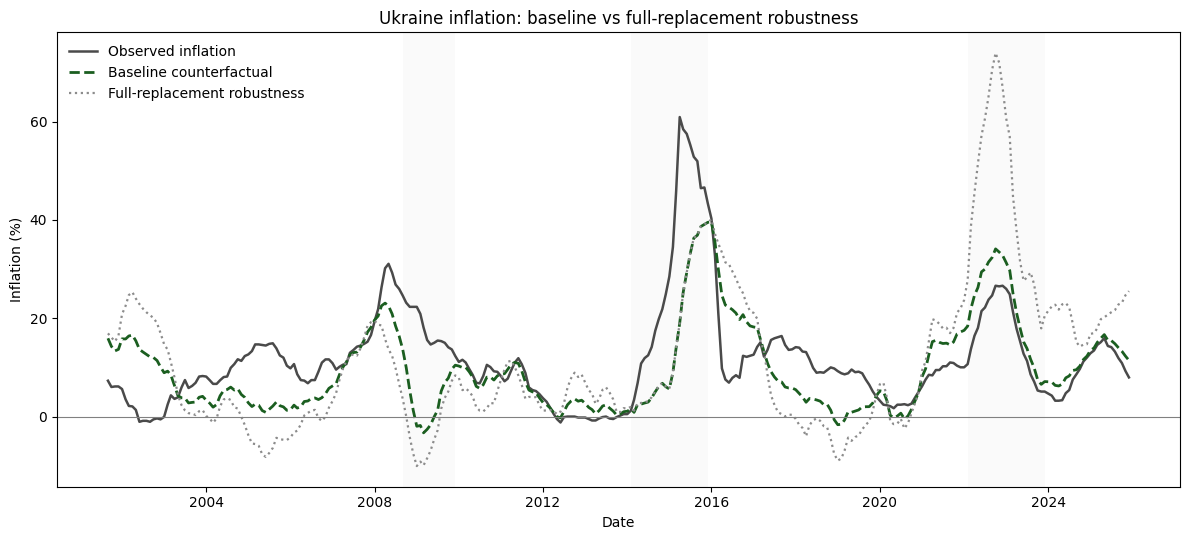

In [116]:
plt.style.use("default")

fig, ax = plt.subplots(figsize=(12, 5.5), facecolor="white")
ax.set_facecolor("white")

observed_color = "#4A4A4A"
baseline_color = "#1B5E20"
full_color = "#8C8C8C"
shade_color = "#D9D9D9"

ax.axvspan(pd.to_datetime("2008-09-01"), pd.to_datetime("2009-12-01"),
           color=shade_color, alpha=0.12, lw=0)
ax.axvspan(pd.to_datetime("2014-02-01"), pd.to_datetime("2015-12-01"),
           color=shade_color, alpha=0.12, lw=0)
ax.axvspan(pd.to_datetime("2022-02-01"), pd.to_datetime("2023-12-01"),
           color=shade_color, alpha=0.12, lw=0)

ax.plot(
    compare_robust["date"],
    compare_robust["ukraine_inflation_yoy"],
    color=observed_color,
    linewidth=1.8,
    label="Observed inflation"
)

ax.plot(
    compare_robust["date"],
    compare_robust["baseline_cf"],
    color=baseline_color,
    linewidth=2.0,
    linestyle="--",
    label="Baseline counterfactual"
)

ax.plot(
    compare_robust["date"],
    compare_robust["full_replacement_cf"],
    color=full_color,
    linewidth=1.6,
    linestyle=":",
    label="Full-replacement robustness"
)

ax.axhline(0, color="gray", linewidth=0.8)

ax.set_title("Ukraine inflation: baseline vs full-replacement robustness", fontsize=12)
ax.set_xlabel("Date")
ax.set_ylabel("Inflation (%)")
ax.legend(frameon=False, loc="upper left")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "counterfactual_robustness_full_replacement.png", dpi=300, bbox_inches="tight")
plt.show()
